# Task 1 — Historical PM2.5 Data and Trend Attributes (Initial Approach)

This notebook engineers historical PM2.5 features for London Marylebone Road covering 2021–2025 (as per the provided data).

**Features produced:**

- Raw lag features — PM2.5 values from previous 1, 2, 3, 7, 14 and 30 days.
- Rolling averages — 3, 7, 14 and 30 day rolling means.
- Rolling statistics — standard deviation, min, max.
- Rate of change — day-on-day difference, 7-day difference, percentage change, and rate of acceleration.
- Seasonal components — trend, seasonality, and residual extracted via decomposition.
- Trend Attributes (from Wood 2024) — A set of 14 trend attributes.
- Cyclical Features — Sine and cosine transformations for day of year, day of week, and day of month.

**Files needed:**

- `PM2.5_AirQualityDataDaily_2021-2025.csv` — upload to `/content/`

## 1.1. Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


## 1.2. Load and Merge PM2.5 Data
Load the 2021-2025 CSV file and combine into one continuous daily series for London Marylebone Road.

In [22]:
def load_defra_single_station(filepath):
    """
    Load a DEFRA daily CSV for a single station.
    Skips 11 metadata rows, returns clean date + pm25 dataframe.
    """
    raw = pd.read_csv(filepath, skiprows=11, header=None,
                      usecols=[0, 1], names=['date', 'pm25'])
    # Drop non-date rows (e.g. blank rows, End row at bottom)
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

# Load only the 2021-2025 file
df = load_defra_single_station('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')

# Sort and drop duplicates
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)

# Add station name
df['station'] = 'London Marylebone Road'

print(f'Combined shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing PM2.5 values: {df["pm25"].isna().sum()}')
display(df.head(10))

Combined shape: (720, 3)
Date range: 2021-01-01 to 2025-12-12
Missing PM2.5 values: 33


,date,pm25,station
0,2021-01-01,17.167,London Marylebone Road
1,2021-01-02,13.724,London Marylebone Road
2,2021-01-03,26.917,London Marylebone Road
3,2021-01-04,17.167,London Marylebone Road
4,2021-01-05,10.000,London Marylebone Road
5,2021-01-06,12.385,London Marylebone Road
6,2021-01-07,7.720,London Marylebone Road
7,2021-01-08,4.333,London Marylebone Road
8,2021-01-09,6.417,London Marylebone Road
9,2021-01-10,6.083,London Marylebone Road


## 1.3. Basic Cleaning
Remove impossible values and fill the time index so it is fully continuous.

Negative values removed: 0
Missing values after reindex: 1120 (62.0%)
Total days in series: 1807


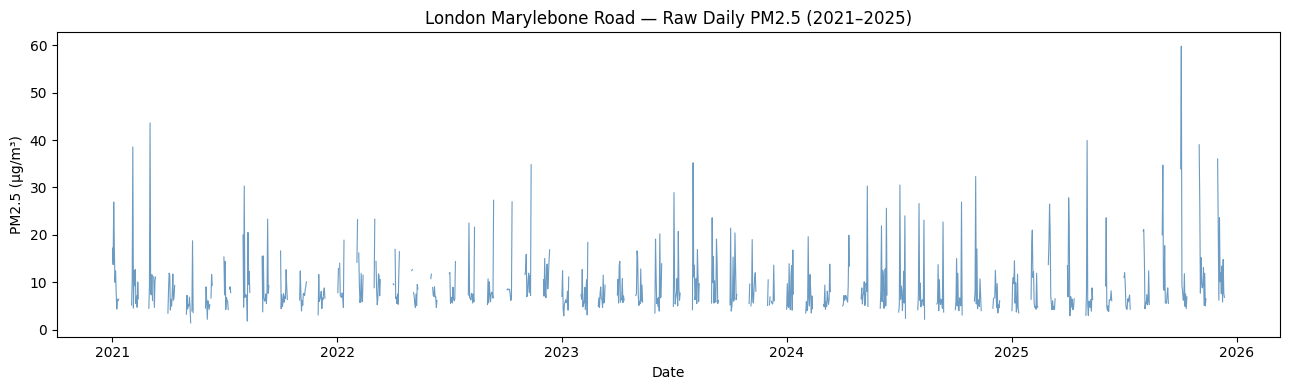

Saved: pm25_raw_series.png


In [23]:
# Drop negative values — physically impossible for PM2.5
negatives = (df['pm25'] < 0).sum()
df = df[~(df['pm25'] < 0)].copy()
print(f'Negative values removed: {negatives}')

# Reindex to a complete daily date range so gaps are visible
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()
df['station'] = 'London Marylebone Road'

missing_after = df['pm25'].isna().sum()
print(f'Missing values after reindex: {missing_after} ({missing_after/len(df)*100:.1f}%)')
print(f'Total days in series: {len(df)}')

# Plot raw time series
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['pm25'], linewidth=0.8, color='steelblue', alpha=0.8)
ax.set_title('London Marylebone Road — Raw Daily PM2.5 (2021–2025)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('pm25_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_raw_series.png')

## 1.4. Fill Missing Values
Use linear interpolation for short gaps (1-3 days) and forward/backward fill for any remaining gaps.

In [24]:
# Record which values were originally observed vs filled
df['was_observed'] = df['pm25'].notna()

# Linear interpolation — limit to 3 consecutive days
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3, limit_area='inside')

# Forward fill then backward fill for any remaining gaps at edges
df['pm25'] = df['pm25'].ffill().bfill()

df['pm25_imputed'] = ~df['was_observed']

print(f'Values after interpolation: {df["pm25"].notna().sum()}')
print(f'Still missing: {df["pm25"].isna().sum()}')
print(f'Imputed rows: {df["pm25_imputed"].sum()}')
display(df.head())

Values after interpolation: 1807
Still missing: 0
Imputed rows: 1120


,date,pm25,station,was_observed,pm25_imputed
0,2021-01-01,17.167,London Marylebone Road,True,False
1,2021-01-02,13.724,London Marylebone Road,True,False
2,2021-01-03,26.917,London Marylebone Road,True,False
3,2021-01-04,17.167,London Marylebone Road,True,False
4,2021-01-05,10.000,London Marylebone Road,True,False


## 1.5. Raw Lag Features
Past PM2.5 values as direct inputs — what the model saw on previous days.

In [26]:
# Lag features — PM2.5 value from N days ago
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'pm25_lag_{lag}d'] = df['pm25'].shift(lag)

lag_features = [f'pm25_lag_{lag}d' for lag in [1, 2, 3, 7, 14, 30]]

print(f'Lag features added: {lag_features}')
print()
print('Sample (first 10 rows):')
print(df[['date', 'pm25'] + lag_features].head(10).to_string(index=False))

Lag features added: ['pm25_lag_1d', 'pm25_lag_2d', 'pm25_lag_3d', 'pm25_lag_7d', 'pm25_lag_14d', 'pm25_lag_30d']

Sample (first 10 rows):
      date   pm25  pm25_lag_1d  pm25_lag_2d  pm25_lag_3d  pm25_lag_7d  pm25_lag_14d  pm25_lag_30d
2021-01-01 17.167          NaN          NaN          NaN          NaN           NaN           NaN
2021-01-02 13.724       17.167          NaN          NaN          NaN           NaN           NaN
2021-01-03 26.917       13.724       17.167          NaN          NaN           NaN           NaN
2021-01-04 17.167       26.917       13.724       17.167          NaN           NaN           NaN
2021-01-05 10.000       17.167       26.917       13.724          NaN           NaN           NaN
2021-01-06 12.385       10.000       17.167       26.917          NaN           NaN           NaN
2021-01-07  7.720       12.385       10.000       17.167          NaN           NaN           NaN
2021-01-08  4.333        7.720       12.385       10.000       17.167         

## 1.6. Rolling Averages and Statistics
Smoothed representations of past PM2.5 levels — capture short and medium term trends.

Rolling features added: 10
['rolling_mean_3d', 'rolling_mean_7d', 'rolling_mean_14d', 'rolling_mean_30d', 'rolling_std_7d', 'rolling_std_30d', 'rolling_min_7d', 'rolling_min_30d', 'rolling_max_7d', 'rolling_max_30d']


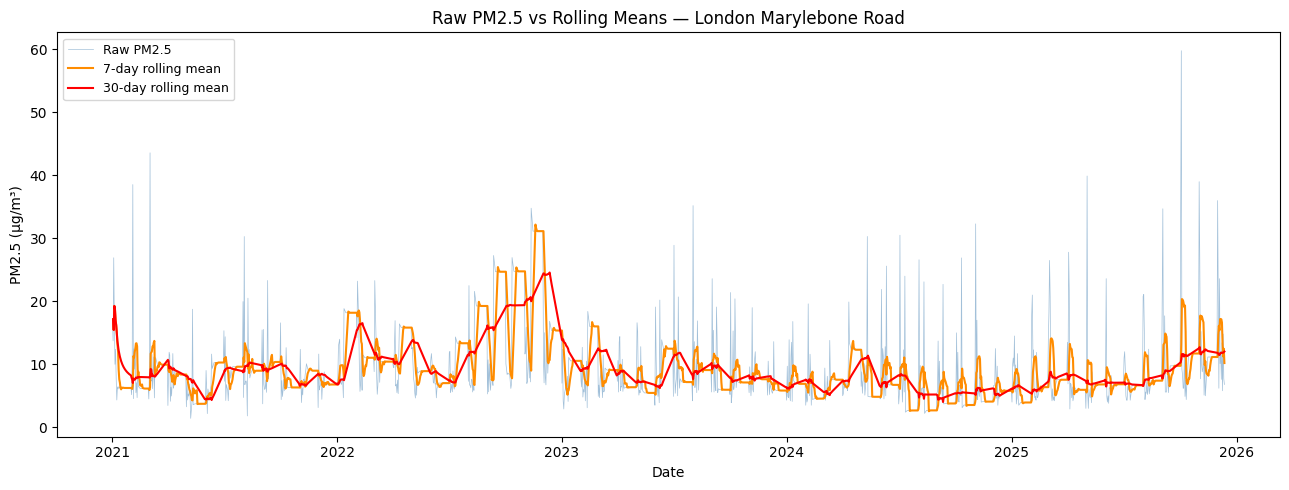

Saved: pm25_rolling_means.png


In [27]:
# Rolling means
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}d'] = df['pm25'].shift(1).rolling(window, min_periods=1).mean()

# Rolling std, min, max
for window in [7, 30]:
    df[f'rolling_std_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=2).std()
    df[f'rolling_min_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).min()
    df[f'rolling_max_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).max()

rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30]] +
    [f'rolling_std_{w}d'  for w in [7, 30]] +
    [f'rolling_min_{w}d'  for w in [7, 30]] +
    [f'rolling_max_{w}d'  for w in [7, 30]]
)

print(f'Rolling features added: {len(rolling_features)}')
print(rolling_features)

# Plot rolling means vs raw
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['pm25'], linewidth=0.5, color='steelblue', alpha=0.5, label='Raw PM2.5')
ax.plot(df['date'], df['rolling_mean_7d'],  linewidth=1.5, color='darkorange', label='7-day rolling mean')
ax.plot(df['date'], df['rolling_mean_30d'], linewidth=1.5, color='red',        label='30-day rolling mean')
ax.set_title('Raw PM2.5 vs Rolling Means — London Marylebone Road', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_rolling_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_rolling_means.png')

## 1.7. Rate of Change Features
How fast is PM2.5 changing? Captures pollution episodes building up or clearing.

Rate of change features added: ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

      date      pm25   diff_1d    diff_7d  diff_30d  pct_change_1d  pct_change_7d  diff_of_diff
2021-01-01 17.167000       NaN        NaN       NaN            NaN            NaN           NaN
2021-01-02 13.724000       NaN        NaN       NaN            NaN            NaN           NaN
2021-01-03 26.917000 -3.443000        NaN       NaN     -20.055921            NaN           NaN
2021-01-04 17.167000 13.193000        NaN       NaN      96.130866            NaN  1.663600e+01
2021-01-05 10.000000 -9.750000        NaN       NaN     -36.222462            NaN -2.294300e+01
2021-01-06 12.385000 -7.167000        NaN       NaN     -41.748704            NaN  2.583000e+00
2021-01-07  7.720000  2.385000        NaN       NaN      23.850000            NaN  9.552000e+00
2021-01-08  4.333000 -4.665000        NaN       NaN     -37.666532            NaN -7.050000e+00
2021-01-09  6.41700

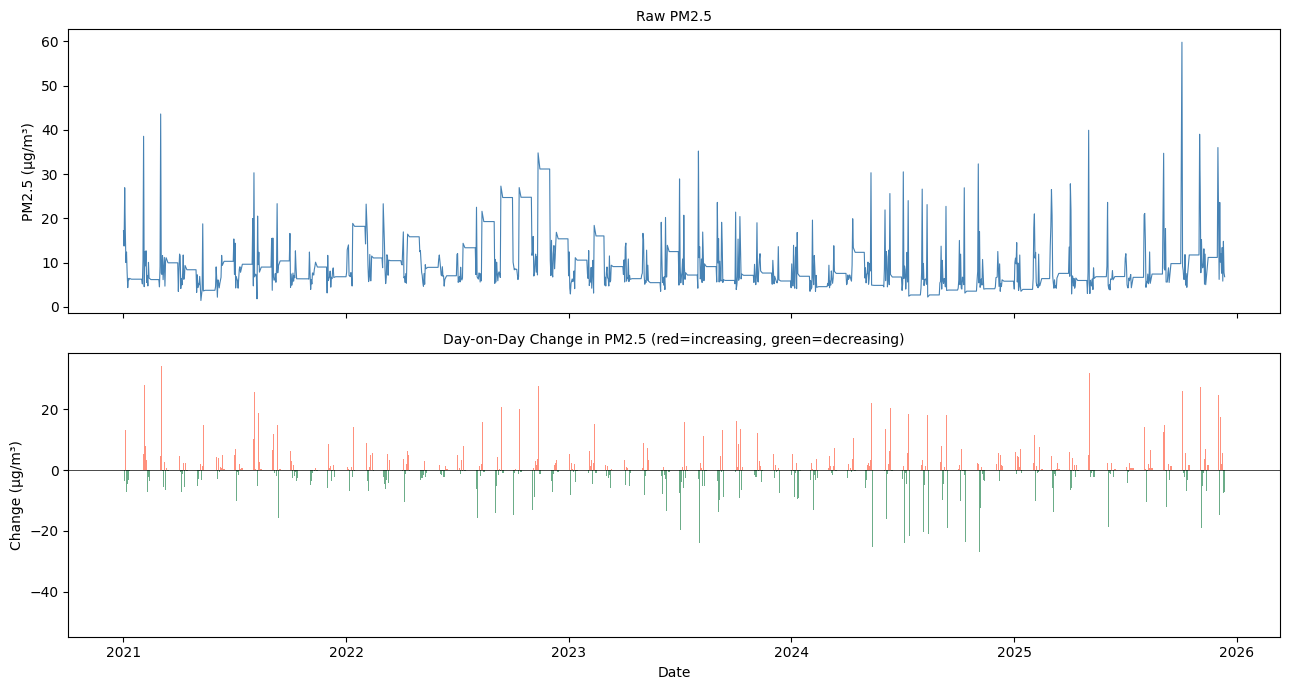

Saved: pm25_rate_of_change.png


In [28]:
# Day-on-day difference (shift so we use yesterday's value, not today's)
df['diff_1d']      = df['pm25'].shift(1).diff(1)    # change from day before
df['diff_7d']      = df['pm25'].shift(1).diff(7)    # change over past 7 days
df['diff_30d']     = df['pm25'].shift(1).diff(30)   # change over past 30 days

# Percentage change from previous day
df['pct_change_1d'] = df['pm25'].shift(1).pct_change(1) * 100
df['pct_change_7d'] = df['pm25'].shift(1).pct_change(7) * 100

# Rate of acceleration (change of change)
df['diff_of_diff'] = df['diff_1d'].diff(1)

roc_features = ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

print(f'Rate of change features added: {roc_features}')
print()
print(df[['date', 'pm25'] + roc_features].head(15).to_string(index=False))

# Plot day-on-day difference
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df['date'], df['pm25'], linewidth=0.8, color='steelblue')
axes[0].set_title('Raw PM2.5', fontsize=10)
axes[0].set_ylabel('PM2.5 (µg/m³)')

axes[1].bar(df['date'], df['diff_1d'], color=[
    'tomato' if x > 0 else 'seagreen' for x in df['diff_1d'].fillna(0)
], width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Day-on-Day Change in PM2.5 (red=increasing, green=decreasing)', fontsize=10)
axes[1].set_ylabel('Change (µg/m³)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('pm25_rate_of_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_rate_of_change.png')

## 1.8. Seasonal Decomposition
Extract trend and seasonality components from the PM2.5 signal.

Seasonal features added: ['seasonal_trend', 'seasonal_component', 'seasonal_residual']


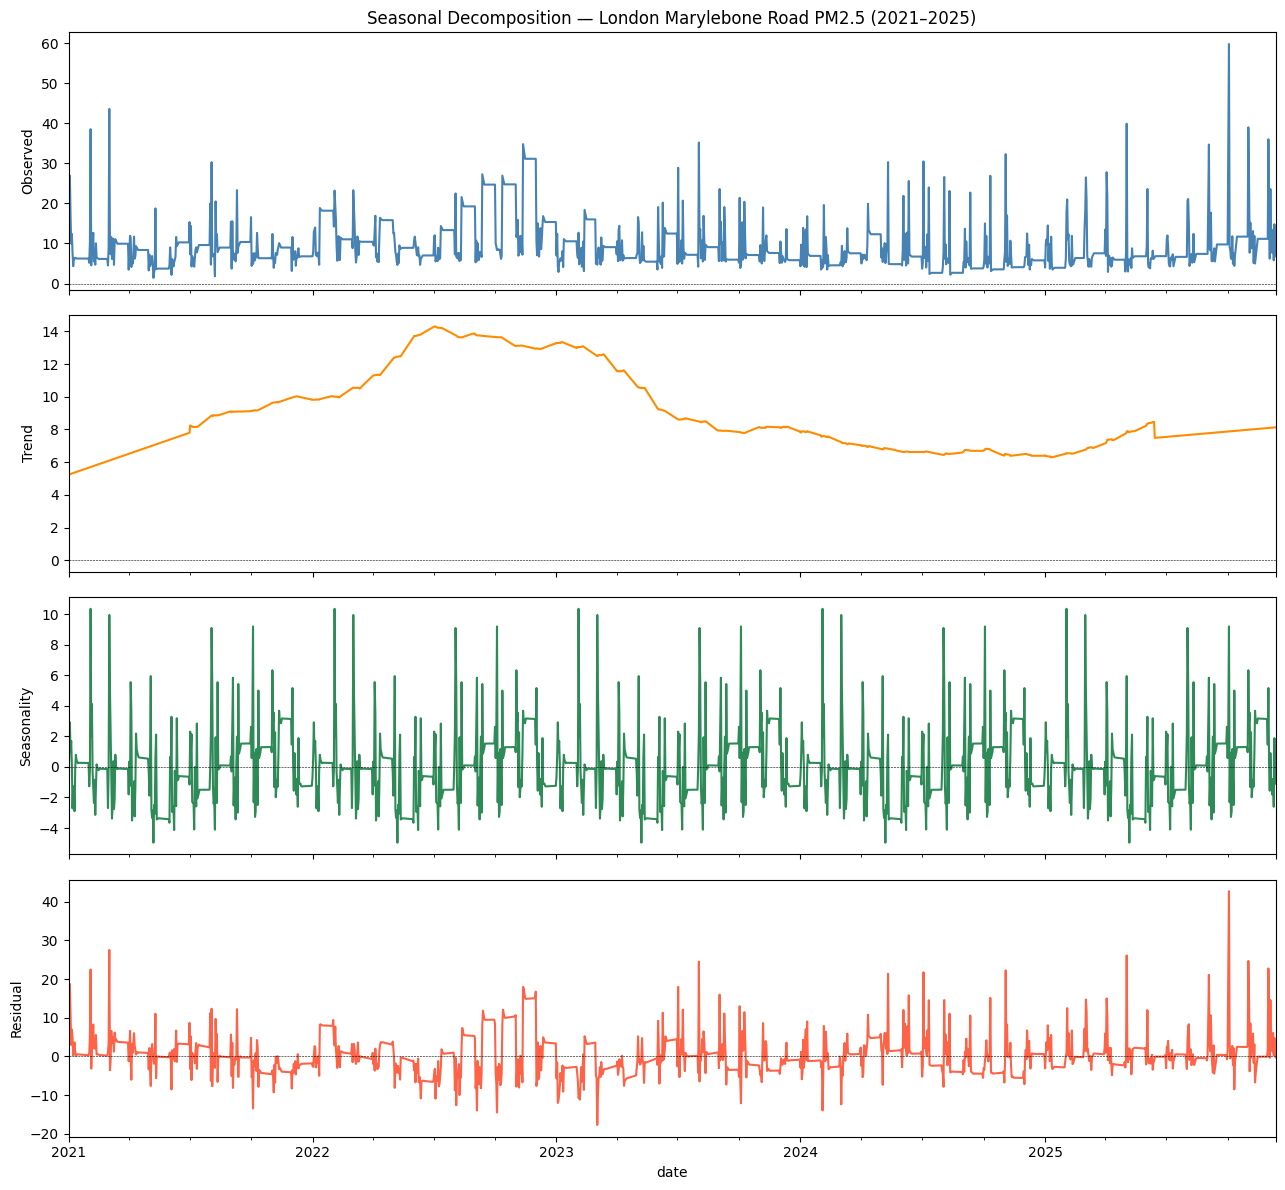

Saved: pm25_seasonal_decomposition.png


In [30]:
# Seasonal decomposition — requires complete series with no NaNs
pm25_series = df.set_index('date')['pm25'].fillna(method='ffill')

# Annual seasonality period = 365 days
decomp = seasonal_decompose(pm25_series, model='additive', period=365, extrapolate_trend='freq')

# Add components back to df as features
df['seasonal_trend']      = decomp.trend.values
df['seasonal_component']  = decomp.seasonal.values
df['seasonal_residual']   = decomp.resid.values

seasonal_features = ['seasonal_trend', 'seasonal_component', 'seasonal_residual']
print(f'Seasonal features added: {seasonal_features}')

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
decomp.observed.plot(ax=axes[0],  color='steelblue');  axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1],     color='darkorange'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2],  color='seagreen');   axes[2].set_ylabel('Seasonality')
decomp.resid.plot(ax=axes[3],     color='tomato');     axes[3].set_ylabel('Residual')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.4, linestyle='--')

axes[0].set_title('Seasonal Decomposition — London Marylebone Road PM2.5 (2021–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('pm25_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_seasonal_decomposition.png')

## 1.9. Extracted Trend Attributes (from Wood 2024)
Based on the univariate approach in Wood (2024) — extracting 14 trend attributes from prior PM2.5 recordings.

In [32]:
# Rolling averages over different windows (using yesterday's value onwards)
for w in [3, 7, 14]:
    df[f'trend_avg_{w}d'] = df['pm25'].shift(1).rolling(w, min_periods=1).mean()

# Differences between specific past days
df['trend_diff_1_2']  = df['pm25'].shift(1) - df['pm25'].shift(2)   # yesterday vs 2 days ago
df['trend_diff_1_7']  = df['pm25'].shift(1) - df['pm25'].shift(7)   # yesterday vs last week
df['trend_diff_7_14'] = df['pm25'].shift(7) - df['pm25'].shift(14)  # last week vs 2 weeks ago

# Rates of change over different windows
df['trend_rate_3d']  = (df['pm25'].shift(1) - df['pm25'].shift(3))  / 3
df['trend_rate_7d']  = (df['pm25'].shift(1) - df['pm25'].shift(7))  / 7
df['trend_rate_14d'] = (df['pm25'].shift(1) - df['pm25'].shift(14)) / 14

# Volatility — rolling standard deviation
df['trend_volatility_7d']  = df['pm25'].shift(1).rolling(7,  min_periods=2).std()
df['trend_volatility_14d'] = df['pm25'].shift(1).rolling(14, min_periods=2).std()

# Ratio of current to rolling mean (how far from recent average)
df['trend_ratio_7d']  = df['pm25'].shift(1) / df[f'rolling_mean_7d'].replace(0, np.nan)
df['trend_ratio_30d'] = df['pm25'].shift(1) / df[f'rolling_mean_30d'].replace(0, np.nan)

# Cumulative sum over past 7 days (total pollution load)
df['trend_cumsum_7d'] = df['pm25'].shift(1).rolling(7, min_periods=1).sum()

trend_attr_features = [
    'trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d',
    'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14',
    'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d',
    'trend_volatility_7d', 'trend_volatility_14d',
    'trend_ratio_7d', 'trend_ratio_30d',
    'trend_cumsum_7d'
]

print(f'Trend attribute features added: {len(trend_attr_features)}')
print(trend_attr_features)
print()
print(df[['date', 'pm25'] + trend_attr_features].head(10).to_string(index=False))

Trend attribute features added: 14
['trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d', 'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14', 'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d', 'trend_volatility_7d', 'trend_volatility_14d', 'trend_ratio_7d', 'trend_ratio_30d', 'trend_cumsum_7d']

      date   pm25  trend_avg_3d  trend_avg_7d  trend_avg_14d  trend_diff_1_2  trend_diff_1_7  trend_diff_7_14  trend_rate_3d  trend_rate_7d  trend_rate_14d  trend_volatility_7d  trend_volatility_14d  trend_ratio_7d  trend_ratio_30d  trend_cumsum_7d
2021-01-01 17.167           NaN           NaN            NaN             NaN             NaN              NaN            NaN            NaN             NaN                  NaN                   NaN             NaN              NaN              NaN
2021-01-02 13.724     17.167000     17.167000      17.167000             NaN             NaN              NaN            NaN            NaN             NaN                  NaN                   NaN        

## 1.10. Cyclical Features
This section generates cyclical features for 'day of year', 'day of week', and 'day of month'. These features are encoded using sine and cosine transformations to represent their periodic nature, enabling models to capture daily, weekly, and annual fluctuations in PM2.5 levels.

In [33]:
# Day of year
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)

# Day of week (Monday=0, Sunday=6)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)

# Day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)

cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

print(f'Cyclical features added: {cyclical_features}')
print('\nSample (first 10 rows with new features):')
print(df[['date'] + cyclical_features].head(10).to_string(index=False))

Cyclical features added: ['day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos']

Sample (first 10 rows with new features):
      date  day_of_year_sin  day_of_year_cos  day_of_week_sin  day_of_week_cos  day_of_month_sin  day_of_month_cos
2021-01-01         0.017213         0.999852        -0.433884        -0.900969          0.201299          0.979530
2021-01-02         0.034422         0.999407        -0.974928        -0.222521          0.394356          0.918958
2021-01-03         0.051620         0.998667        -0.781831         0.623490          0.571268          0.820763
2021-01-04         0.068802         0.997630         0.000000         1.000000          0.724793          0.688967
2021-01-05         0.085965         0.996298         0.781831         0.623490          0.848644          0.528964
2021-01-06         0.103102         0.994671         0.974928        -0.222521          0.937752          0.347305
2021-01-07

## 1.11. Rebuilding DataFrame with All Features (to fix NameError and ensure all features are available for correlation)

In [34]:
# Re-load raw data
def load_defra_single_station(filepath):
    raw = pd.read_csv(filepath, skiprows=11, header=None, usecols=[0, 1], names=['date', 'pm25'])
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

df = load_defra_single_station('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)
df['station'] = 'London Marylebone Road'

# Basic Cleaning
df = df[~(df['pm25'] < 0)].copy()
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()
df['station'] = 'London Marylebone Road'

# Fill Missing Values
df['was_observed'] = df['pm25'].notna()
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3, limit_area='inside')
df['pm25'] = df['pm25'].ffill().bfill()
df['pm25_imputed'] = ~df['was_observed']

# Raw Lag Features
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'pm25_lag_{lag}d'] = df['pm25'].shift(lag)
lag_features = [f'pm25_lag_{lag}d' for lag in [1, 2, 3, 7, 14, 30]]

# Rolling Averages and Statistics
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}d'] = df['pm25'].shift(1).rolling(window, min_periods=1).mean()
for window in [7, 30]:
    df[f'rolling_std_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=2).std()
    df[f'rolling_min_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).min()
    df[f'rolling_max_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).max()
rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30]] +
    [f'rolling_std_{w}d'  for w in [7, 30]] +
    [f'rolling_min_{w}d'  for w in [7, 30]] +
    [f'rolling_max_{w}d'  for w in [7, 30]]
)

# Rate of Change Features
df['diff_1d']      = df['pm25'].shift(1).diff(1)
df['diff_7d']      = df['pm25'].shift(1).diff(7)
df['diff_30d']     = df['pm25'].shift(1).diff(30)
df['pct_change_1d'] = df['pm25'].shift(1).pct_change(1) * 100
df['pct_change_7d'] = df['pm25'].shift(1).pct_change(7) * 100
df['diff_of_diff'] = df['diff_1d'].diff(1)
roc_features = ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

# Seasonal Decomposition
pm25_series = df.set_index('date')['pm25'].fillna(method='ffill')
decomp = seasonal_decompose(pm25_series, model='additive', period=365, extrapolate_trend='freq')
df['seasonal_trend']      = decomp.trend.values
df['seasonal_component']  = decomp.seasonal.values
df['seasonal_residual']   = decomp.resid.values
seasonal_features = ['seasonal_trend', 'seasonal_component', 'seasonal_residual']

# Extracted Trend Attributes (from Wood 2024)
for w in [3, 7, 14]:
    df[f'trend_avg_{w}d'] = df['pm25'].shift(1).rolling(w, min_periods=1).mean()
df['trend_diff_1_2']  = df['pm25'].shift(1) - df['pm25'].shift(2)
df['trend_diff_1_7']  = df['pm25'].shift(1) - df['pm25'].shift(7)
df['trend_diff_7_14'] = df['pm25'].shift(7) - df['pm25'].shift(14)
df['trend_rate_3d']  = (df['pm25'].shift(1) - df['pm25'].shift(3))  / 3
df['trend_rate_7d']  = (df['pm25'].shift(1) - df['pm25'].shift(7))  / 7
df['trend_rate_14d'] = (df['pm25'].shift(1) - df['pm25'].shift(14)) / 14
df['trend_volatility_7d']  = df['pm25'].shift(1).rolling(7,  min_periods=2).std()
df['trend_volatility_14d'] = df['pm25'].shift(1).rolling(14, min_periods=2).std()
df['trend_ratio_7d']  = df['pm25'].shift(1) / df[f'rolling_mean_7d'].replace(0, np.nan)
df['trend_ratio_30d'] = df['pm25'].shift(1) / df[f'rolling_mean_30d'].replace(0, np.nan)
df['trend_cumsum_7d'] = df['pm25'].shift(1).rolling(7, min_periods=1).sum()
trend_attr_features = [
    'trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d',
    'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14',
    'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d',
    'trend_volatility_7d', 'trend_volatility_14d',
    'trend_ratio_7d', 'trend_ratio_30d',
    'trend_cumsum_7d'
]

# Cyclical Features (from previous step)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

# Define the full list of features after all steps
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

print(f'DataFrame rebuilt with all features. New shape: {df.shape}')
print(f'Total features in all_features_updated: {len(all_features_updated)}')
display(df.head())

DataFrame rebuilt with all features. New shape: (1807, 50)
Total features in all_features_updated: 45


,date,pm25,station,was_observed,pm25_imputed,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_7d,pm25_lag_14d,...,trend_volatility_14d,trend_ratio_7d,trend_ratio_30d,trend_cumsum_7d,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos
0,2021-01-01,17.167,London Marylebone Road,True,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.017213,0.999852,-0.433884,-0.900969,0.201299,0.979530
1,2021-01-02,13.724,London Marylebone Road,True,False,17.167,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,17.167,0.034422,0.999407,-0.974928,-0.222521,0.394356,0.918958
2,2021-01-03,26.917,London Marylebone Road,True,False,13.724,17.167,NaN,NaN,NaN,...,2.434569,0.888544,0.888544,30.891,0.051620,0.998667,-0.781831,0.623490,0.571268,0.820763
3,2021-01-04,17.167,London Marylebone Road,True,False,26.917,13.724,17.167,NaN,NaN,...,6.843147,1.396883,1.396883,57.808,0.068802,0.997630,0.000000,1.000000,0.724793,0.688967
4,2021-01-05,10.000,London Marylebone Road,True,False,17.167,26.917,13.724,NaN,NaN,...,5.685425,0.915879,0.915879,74.975,0.085965,0.996298,0.781831,0.623490,0.848644,0.528964


## 1.12. Feature Correlation with PM2.5 (Updated)
This section re-evaluates feature correlation with the next day's PM2.5 level, including newly added cyclical components. The top 15 features strongest correlated with future PM2.5 values are visualized to assess their predictive power.

Top 15 features correlated with next-day PM2.5 (updated):
rolling_mean_3d      0.588
trend_avg_3d         0.588
rolling_mean_7d      0.571
trend_avg_7d         0.571
trend_cumsum_7d      0.566
rolling_min_7d       0.546
pm25_lag_1d          0.543
rolling_mean_30d     0.538
pm25_lag_30d         0.525
trend_avg_14d        0.519
rolling_mean_14d     0.519
pm25_lag_2d          0.504
pm25_lag_3d          0.451
seasonal_residual    0.445
seasonal_trend       0.391


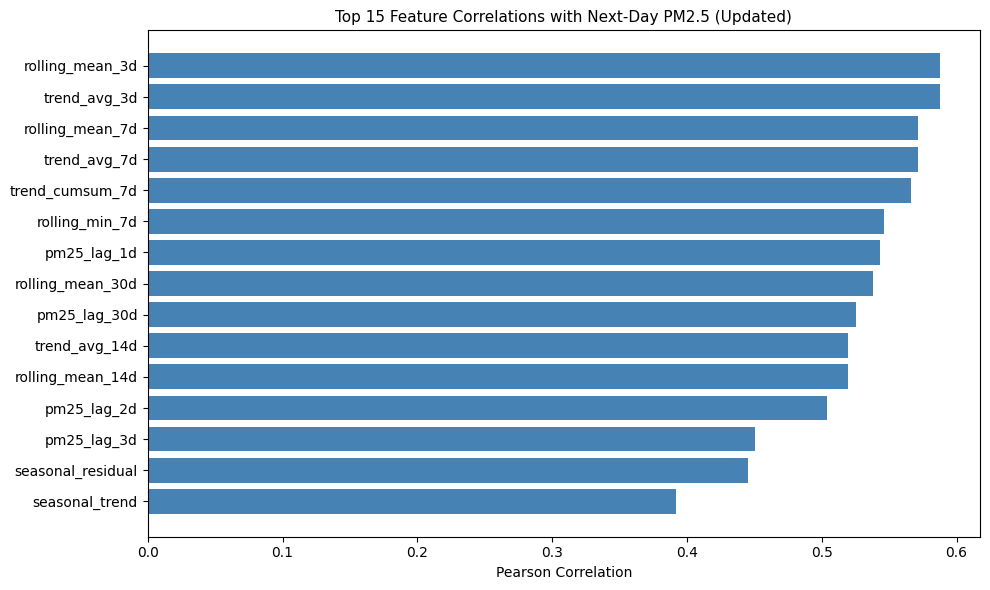

Saved: pm25_feature_correlations_updated.png


In [35]:
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

# Correlation with pm25 (next day — shifted back)
df['pm25_next_day'] = df['pm25'].shift(-1)  # target: tomorrow's PM2.5

corr_with_target_updated = (
    df[all_features_updated + ['pm25_next_day']]
    .corr()['pm25_next_day']
    .drop('pm25_next_day')
    .sort_values(ascending=False)
)

print('Top 15 features correlated with next-day PM2.5 (updated):')
print(corr_with_target_updated.head(15).round(3).to_string())

# Bar chart
top15_updated = corr_with_target_updated.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in top15_updated.values]
ax.barh(top15_updated.index[::-1], top15_updated.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 15 Feature Correlations with Next-Day PM2.5 (Updated)', fontsize=11)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('pm25_feature_correlations_updated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_feature_correlations_updated.png')

## 1.13. Save Output
This step saves the DataFrame, containing all engineered historical PM2.5 trend attributes and cyclical features, to pm25_historical_features_updated.csv. A summary of the feature engineering process and the final DataFrame shape is also displayed.

In [36]:
# Drop the target shift column before saving
df = df.drop(columns=['pm25_next_day'], errors='ignore')

df.to_csv('pm25_historical_features_updated.csv', index=False)
print('Saved: pm25_historical_features_updated.csv')

print(f"""
=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Lag features          : {len(lag_features)}
Rolling features      : {len(rolling_features)}
Rate of change        : {len(roc_features)}
Seasonal components   : {len(seasonal_features)}
Trend attributes      : {len(trend_attr_features)}
Cyclical features     : {len(cyclical_features)}
------------------------------
Total features added  : {len(all_features_updated)}
Final df shape        : {df.shape}
==============================
""")

display(df.head(10))

Saved: pm25_historical_features_updated.csv

=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-12
Total records  : 1,807

Lag features          : 6
Rolling features      : 10
Rate of change        : 6
Seasonal components   : 3
Trend attributes      : 14
Cyclical features     : 6
------------------------------
Total features added  : 45
Final df shape        : (1807, 50)



,date,pm25,station,was_observed,pm25_imputed,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_7d,pm25_lag_14d,...,trend_volatility_14d,trend_ratio_7d,trend_ratio_30d,trend_cumsum_7d,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos
0,2021-01-01,17.167,London Marylebone Road,True,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.017213,0.999852,-0.433884,-0.900969,0.201299,0.979530
1,2021-01-02,13.724,London Marylebone Road,True,False,17.167,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,17.167,0.034422,0.999407,-0.974928,-0.222521,0.394356,0.918958
2,2021-01-03,26.917,London Marylebone Road,True,False,13.724,17.167,NaN,NaN,NaN,...,2.434569,0.888544,0.888544,30.891,0.051620,0.998667,-0.781831,0.623490,0.571268,0.820763
3,2021-01-04,17.167,London Marylebone Road,True,False,26.917,13.724,17.167,NaN,NaN,...,6.843147,1.396883,1.396883,57.808,0.068802,0.997630,0.000000,1.000000,0.724793,0.688967
4,2021-01-05,10.000,London Marylebone Road,True,False,17.167,26.917,13.724,NaN,NaN,...,5.685425,0.915879,0.915879,74.975,0.085965,0.996298,0.781831,0.623490,0.848644,0.528964
5,2021-01-06,12.385,London Marylebone Road,True,False,10.000,17.167,26.917,NaN,NaN,...,6.287581,0.588408,0.588408,84.975,0.103102,0.994671,0.974928,-0.222521,0.937752,0.347305
6,2021-01-07,7.720,London Marylebone Road,True,False,12.385,10.000,17.167,NaN,NaN,...,5.930342,0.763250,0.763250,97.360,0.120208,0.992749,0.433884,-0.900969,0.988468,0.151428
7,2021-01-08,4.333,London Marylebone Road,True,False,7.720,12.385,10.000,17.167,NaN,...,6.296435,0.514275,0.514275,105.080,0.137279,0.990532,-0.433884,-0.900969,0.998717,-0.050649
8,2021-01-09,6.417,London Marylebone Road,True,False,4.333,7.720,12.385,13.724,NaN,...,6.945150,0.328806,0.316818,92.246,0.154309,0.988023,-0.974928,-0.222521,0.968077,-0.250653
9,2021-01-10,6.083,London Marylebone Road,True,False,6.417,4.333,7.720,26.917,NaN,...,6.932642,0.528838,0.498601,84.939,0.171293,0.985220,-0.781831,0.623490,0.897805,-0.440394


## Task 1 part 2 — Complete Historical PM2.5 Data and Trend Attributes (Hiruni'sWork)

### 2.1. Overview and Purpose

This notebook completes the feature engineering task for the group PM2.5 forecasting project.

It includes:

*   Historical PM2.5 data features.
*   Extracted trend attributes.
*   Seasonal components.
*   Spatiotemporal peer-station feature section with DTW logic.
*   Correct save path inside `data/features/`.

**Important dataset note** The current uploaded dataset is a single-station daily dataset for London Marylebone Road. Therefore, true spatiotemporal peer-station features cannot be calculated from this dataset alone.

The notebook still includes the peer-station DTW section, but it only activates when the input dataset contains at least two stations.

**Purpose of Historical PM2.5 data features.** This notebook performs feature engineering for PM2.5 air-quality forecasting. The aim is to transform raw daily PM2.5 observations into useful time-series features that can support machine learning forecasting models.

The engineered features include historical lag values, rolling trend attributes, rate-of-change measures, seasonal cyclical features, and a DTW-based peer-station feature section for future multi-station data.

### 2.2. Imports

In [2]:
from pathlib import Path
import csv
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

print("Imports loaded successfully.")

Imports loaded successfully.


### 2.3. Setup Data and Output Directories

In [20]:
# =====================================
# Load uploaded UK-Air PM2.5 dataset
# =====================================

current_dir = Path.cwd()

# Works when notebook is in AIR/notebooks/
if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent

# Works when notebook is opened from AIR/
elif (current_dir / "data").exists():
    PROJECT_ROOT = current_dir

# Fallback for local machine
else:
    PROJECT_ROOT = Path.home() / "AIR"

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FEATURE_OUTPUT_DIR = PROJECT_ROOT / "data" / "features"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Current notebook folder:", current_dir)
print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Feature output folder:", FEATURE_OUTPUT_DIR)
print("Figure output folder:", FIGURE_DIR)

Current notebook folder: /content
Project root: /content
Raw data folder: /content/data/raw
Feature output folder: /content/data/features
Figure output folder: /content/outputs/figures


### 2.4. Load PM2.5 Dataset

In [21]:
DATA_FILE = Path("/content/PM2.5_AirQualityDataDaily_2021-2025.csv")

print("Looking for file:")
print(DATA_FILE)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"File not found: {DATA_FILE}\n"
        "Please place the CSV file inside data/raw/ in the GitHub project."
    )

def read_station_name(filepath):
    """Read station name from UK-Air metadata rows."""

    try:
        with open(filepath, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
            rows = list(csv.reader(f))

        station_name = rows[3][1].strip()

        if station_name.lower() in ["nan", "", "none"]:
            station_name = "London Marylebone Road"

    except Exception:
        station_name = "London Marylebone Road"

    return station_name

def load_defra_single_station(filepath):
    """
    Load a DEFRA/UK-Air single-station daily PM2.5 CSV file.

    The uploaded UK-Air file contains metadata rows followed by a data header:
    Date, PM2.5 particulate matter (Daily measured), Status
    """

    station_name = read_station_name(filepath)

    # Read actual data after metadata rows
    raw = pd.read_csv(filepath, skiprows=10, header=0)

    raw = raw.rename(columns={
        raw.columns[0]: "date",
        raw.columns[1]: "pm25_raw"
    })

    if raw.shape[1] >= 3:
        raw = raw.rename(columns={raw.columns[2]: "status_raw"})
    else:
        raw["status_raw"] = np.nan

    raw["date_raw"] = raw["date"].astype(str)

    # Correct for ISO date format such as 2021-01-01
    raw["date"] = pd.to_datetime(
        raw["date_raw"],
        format="%Y-%m-%d",
        errors="coerce")

    # Fallback for any non-ISO date rows
    missing_dates = raw["date"].isna()

    if missing_dates.any():
        raw.loc[missing_dates, "date"] = pd.to_datetime(
            raw.loc[missing_dates, "date_raw"],
            errors="coerce",
            dayfirst=True
        )

    raw["pm25_raw"] = pd.to_numeric(raw["pm25_raw"], errors="coerce")

    raw = raw.dropna(subset=["date"]).copy()
    raw["date"] = raw["date"].dt.normalize()

    raw["station"] = station_name
    raw["source_file"] = Path(filepath).name

    raw = raw[[
        "date",
        "date_raw",
        "station",
        "pm25_raw",
        "status_raw",
        "source_file"
    ]]

    raw = (
        raw
        .sort_values(["station", "date"])
        .drop_duplicates(subset=["station", "date"])
        .reset_index(drop=True)
    )

    return raw

df = load_defra_single_station(DATA_FILE)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)
print("Station:", df["station"].iloc[0])
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing PM2.5 count:", df["pm25_raw"].isna().sum())
print("Missing PM2.5 percentage:", round(df["pm25_raw"].isna().mean() * 100, 2), "%")
df.head(10)

Looking for file:
/content/PM2.5_AirQualityDataDaily_2021-2025.csv

Dataset loaded successfully.
Shape: (1825, 6)
Station: London Marylebone Road
Date range: 2021-01-01 00:00:00 to 2025-12-30 00:00:00
Missing PM2.5 count: 86
Missing PM2.5 percentage: 4.71 %


,date,date_raw,station,pm25_raw,status_raw,source_file
0,2021-01-01,2021-01-01,London Marylebone Road,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
1,2021-01-02,2021-01-02,London Marylebone Road,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
2,2021-01-03,2021-01-03,London Marylebone Road,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
3,2021-01-04,2021-01-04,London Marylebone Road,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
4,2021-01-05,2021-01-05,London Marylebone Road,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
5,2021-01-06,2021-01-06,London Marylebone Road,4.542,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
6,2021-01-07,2021-01-07,London Marylebone Road,15.333,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
7,2021-01-08,2021-01-08,London Marylebone Road,19.958,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
8,2021-01-09,2021-01-09,London Marylebone Road,15.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv
9,2021-01-10,2021-01-10,London Marylebone Road,16.583,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv


2.5. Complete Daily Date Index

In [22]:
full_station_frames = []

for station, station_df in df.groupby("station"):

    full_dates = pd.date_range(
        station_df["date"].min(),
        station_df["date"].max(),
        freq="D"
    )

    full_station = pd.DataFrame({
        "date": full_dates,
        "station": station
    })

    full_station = full_station.merge(
        station_df,
        on=["date", "station"],
        how="left"
    )

    full_station_frames.append(full_station)

df = pd.concat(full_station_frames, ignore_index=True)

df["source_file"] = df["source_file"].fillna(DATA_FILE.name)
df["date_raw"] = df["date_raw"].fillna(df["date"].dt.strftime("%Y-%m-%d"))
df["status_raw"] = df["status_raw"].fillna("Missing calendar day")

df["pm25_missing_flag"] = df["pm25_raw"].isna().astype(int)

print("Completed daily date index.")
print("Shape after daily completion:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing PM2.5 count:", df["pm25_raw"].isna().sum())

df.head()

Completed daily date index.
Shape after daily completion: (1825, 7)
Date range: 2021-01-01 00:00:00 to 2025-12-30 00:00:00
Missing PM2.5 count: 86


,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0


2.6. Timestamp and Seasonal Base Features


In [23]:

df = df.sort_values(["station", "date"]).reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear
df["day_of_week"] = df["date"].dt.day_name()
df["quarter"] = df["date"].dt.quarter

print("Timestamp features created.")

df.head()

Timestamp features created.


,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,year,month,day,day_of_year,day_of_week,quarter
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,1,1,Friday,1
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,2,2,Saturday,1
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,3,3,Sunday,1
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,4,4,Monday,1
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,5,5,Tuesday,1


2.7. PM2.5 Column for Feature Engineering


In [24]:
df["pm25_for_features"] = (
    df.groupby("station")["pm25_raw"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

PM25_FEATURE_COL = "pm25_for_features"

print("Feature source column:", PM25_FEATURE_COL)
print("Missing values in raw PM2.5:", df["pm25_raw"].isna().sum())
print("Missing values in feature PM2.5:", df[PM25_FEATURE_COL].isna().sum())

df[["date", "station", "pm25_raw", "pm25_for_features", "pm25_missing_flag"]].head(15)


Feature source column: pm25_for_features
Missing values in raw PM2.5: 86
Missing values in feature PM2.5: 0


,date,station,pm25_raw,pm25_for_features,pm25_missing_flag
0,2021-01-01,London Marylebone Road,17.167,17.167,0
1,2021-01-02,London Marylebone Road,5.167,5.167,0
2,2021-01-03,London Marylebone Road,4.500,4.500,0
3,2021-01-04,London Marylebone Road,3.458,3.458,0
4,2021-01-05,London Marylebone Road,3.250,3.250,0
5,2021-01-06,London Marylebone Road,4.542,4.542,0
6,2021-01-07,London Marylebone Road,15.333,15.333,0
7,2021-01-08,London Marylebone Road,19.958,19.958,0
8,2021-01-09,London Marylebone Road,15.458,15.458,0
9,2021-01-10,London Marylebone Road,16.583,16.583,0


2.8. Historical PM2.5 Lag Features

In [25]:
lag_days = [1, 2, 3, 6, 7, 12, 14, 30]

for lag in lag_days:
    df[f"pm25_lag_{lag}d"] = (
        df.groupby("station")[PM25_FEATURE_COL]
        .shift(lag)
    )

lag_feature_cols = [f"pm25_lag_{lag}d" for lag in lag_days]

print("Historical PM2.5 lag features created:")
print(lag_feature_cols)

df[["date", "station", "pm25_raw", PM25_FEATURE_COL] + lag_feature_cols].head(15)


Historical PM2.5 lag features created:
['pm25_lag_1d', 'pm25_lag_2d', 'pm25_lag_3d', 'pm25_lag_6d', 'pm25_lag_7d', 'pm25_lag_12d', 'pm25_lag_14d', 'pm25_lag_30d']


,date,station,pm25_raw,pm25_for_features,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_6d,pm25_lag_7d,pm25_lag_12d,pm25_lag_14d,pm25_lag_30d
0,2021-01-01,London Marylebone Road,17.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,5.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,4.500,4.500,5.167,17.167,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,3.458,3.458,4.500,5.167,17.167,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,3.250,3.250,3.458,4.500,5.167,NaN,NaN,NaN,NaN,NaN
5,2021-01-06,London Marylebone Road,4.542,4.542,3.250,3.458,4.500,NaN,NaN,NaN,NaN,NaN
6,2021-01-07,London Marylebone Road,15.333,15.333,4.542,3.250,3.458,17.167,NaN,NaN,NaN,NaN
7,2021-01-08,London Marylebone Road,19.958,19.958,15.333,4.542,3.250,5.167,17.167,NaN,NaN,NaN
8,2021-01-09,London Marylebone Road,15.458,15.458,19.958,15.333,4.542,4.500,5.167,NaN,NaN,NaN
9,2021-01-10,London Marylebone Road,16.583,16.583,15.458,19.958,15.333,3.458,4.500,NaN,NaN,NaN


2.9. Extracted Trend Attributes

In [26]:
shifted_pm25 = df.groupby("station")[PM25_FEATURE_COL].shift(1)

rolling_windows = [3, 6, 7, 12, 14, 30]

for window in rolling_windows:

    df[f"pm25_roll_mean_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_std_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_min_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .min()
        .reset_index(level=0, drop=True)
        )

    df[f"pm25_roll_max_{window}d"] = (
        shifted_pm25
        .groupby(df["station"])
        .rolling(window=window, min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
    )

    df[f"pm25_roll_range_{window}d"] = (
        df[f"pm25_roll_max_{window}d"] - df[f"pm25_roll_min_{window}d"]
    )

rolling_feature_cols = [
    col for col in df.columns
    if col.startswith("pm25_roll_")
]

print("Rolling trend features created:", len(rolling_feature_cols))
print(rolling_feature_cols)

df[["date", "station", PM25_FEATURE_COL] + rolling_feature_cols].head(15)


Rolling trend features created: 30
['pm25_roll_mean_3d', 'pm25_roll_std_3d', 'pm25_roll_min_3d', 'pm25_roll_max_3d', 'pm25_roll_range_3d', 'pm25_roll_mean_6d', 'pm25_roll_std_6d', 'pm25_roll_min_6d', 'pm25_roll_max_6d', 'pm25_roll_range_6d', 'pm25_roll_mean_7d', 'pm25_roll_std_7d', 'pm25_roll_min_7d', 'pm25_roll_max_7d', 'pm25_roll_range_7d', 'pm25_roll_mean_12d', 'pm25_roll_std_12d', 'pm25_roll_min_12d', 'pm25_roll_max_12d', 'pm25_roll_range_12d', 'pm25_roll_mean_14d', 'pm25_roll_std_14d', 'pm25_roll_min_14d', 'pm25_roll_max_14d', 'pm25_roll_range_14d', 'pm25_roll_mean_30d', 'pm25_roll_std_30d', 'pm25_roll_min_30d', 'pm25_roll_max_30d', 'pm25_roll_range_30d']


,date,station,pm25_for_features,pm25_roll_mean_3d,pm25_roll_std_3d,pm25_roll_min_3d,pm25_roll_max_3d,pm25_roll_range_3d,pm25_roll_mean_6d,pm25_roll_std_6d,...,pm25_roll_mean_14d,pm25_roll_std_14d,pm25_roll_min_14d,pm25_roll_max_14d,pm25_roll_range_14d,pm25_roll_mean_30d,pm25_roll_std_30d,pm25_roll_min_30d,pm25_roll_max_30d,pm25_roll_range_30d
0,2021-01-01,London Marylebone Road,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,17.167000,NaN,17.167,17.167,0.000,17.167000,NaN,...,17.167000,NaN,17.167,17.167,0.000,17.167000,NaN,17.167,17.167,0.000
2,2021-01-03,London Marylebone Road,4.500,11.167000,8.485281,5.167,17.167,12.000,11.167000,8.485281,...,11.167000,8.485281,5.167,17.167,12.000,11.167000,8.485281,5.167,17.167,12.000
3,2021-01-04,London Marylebone Road,3.458,8.944667,7.128555,4.500,17.167,12.667,8.944667,7.128555,...,8.944667,7.128555,4.500,17.167,12.667,8.944667,7.128555,4.500,17.167,12.667
4,2021-01-05,London Marylebone Road,3.250,4.375000,0.861330,3.458,5.167,1.709,7.573000,6.434548,...,7.573000,6.434548,3.458,17.167,13.709,7.573000,6.434548,3.458,17.167,13.709
5,2021-01-06,London Marylebone Road,4.542,3.736000,0.669767,3.250,4.500,1.250,6.708400,5.898324,...,6.708400,5.898324,3.250,17.167,13.917,6.708400,5.898324,3.250,17.167,13.917
6,2021-01-07,London Marylebone Road,15.333,3.750000,0.693732,3.250,4.542,1.292,6.347333,5.349242,...,6.347333,5.349242,3.250,17.167,13.917,6.347333,5.349242,3.250,17.167,13.917
7,2021-01-08,London Marylebone Road,19.958,7.708333,6.634680,3.250,15.333,12.083,6.041667,4.608436,...,7.631000,5.948103,3.250,17.167,13.917,7.631000,5.948103,3.250,17.167,13.917
8,2021-01-09,London Marylebone Road,15.458,13.277667,7.910851,4.542,19.958,15.416,8.506833,7.247419,...,9.171875,7.022821,3.250,19.958,16.708,9.171875,7.022821,3.250,19.958,16.708
9,2021-01-10,London Marylebone Road,16.583,16.916333,2.634902,15.333,19.958,4.625,10.333167,7.414532,...,9.870333,6.895333,3.250,19.958,16.708,9.870333,6.895333,3.250,19.958,16.708


In [27]:
# =========================================================
# Difference and rate-of-change trend features
# =========================================================

difference_gaps = [1, 3, 6, 7, 12, 14]

for gap in difference_gaps:

    if f"pm25_lag_{gap}d" in df.columns:
        df[f"pm25_diff_{gap}d"] = (
            df["pm25_lag_1d"] - df[f"pm25_lag_{gap}d"]
        )

        df[f"pm25_rate_change_{gap}d"] = (
            df[f"pm25_diff_{gap}d"] / (df[f"pm25_lag_{gap}d"] + 1e-6)
        )

trend_change_cols = [
    col for col in df.columns
    if col.startswith("pm25_diff_")
    or col.startswith("pm25_rate_change_")
]

print("Difference and rate-of-change features created:", len(trend_change_cols))
print(trend_change_cols)

df[["date", "station", PM25_FEATURE_COL] + trend_change_cols].head(15)

Difference and rate-of-change features created: 12
['pm25_diff_1d', 'pm25_rate_change_1d', 'pm25_diff_3d', 'pm25_rate_change_3d', 'pm25_diff_6d', 'pm25_rate_change_6d', 'pm25_diff_7d', 'pm25_rate_change_7d', 'pm25_diff_12d', 'pm25_rate_change_12d', 'pm25_diff_14d', 'pm25_rate_change_14d']


,date,station,pm25_for_features,pm25_diff_1d,pm25_rate_change_1d,pm25_diff_3d,pm25_rate_change_3d,pm25_diff_6d,pm25_rate_change_6d,pm25_diff_7d,pm25_rate_change_7d,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d
0,2021-01-01,London Marylebone Road,17.167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,London Marylebone Road,5.167,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,London Marylebone Road,4.500,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,London Marylebone Road,3.458,0.0,0.0,-12.667,-0.737869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,London Marylebone Road,3.250,0.0,0.0,-1.709,-0.330753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021-01-06,London Marylebone Road,4.542,0.0,0.0,-1.250,-0.277778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021-01-07,London Marylebone Road,15.333,0.0,0.0,1.084,0.313476,-12.625,-0.735423,NaN,NaN,NaN,NaN,NaN,NaN
7,2021-01-08,London Marylebone Road,19.958,0.0,0.0,12.083,3.717845,10.166,1.967486,-1.834,-0.106833,NaN,NaN,NaN,NaN
8,2021-01-09,London Marylebone Road,15.458,0.0,0.0,15.416,3.394099,15.458,3.435110,14.791,2.862589,NaN,NaN,NaN,NaN
9,2021-01-10,London Marylebone Road,16.583,0.0,0.0,0.125,0.008152,12.000,3.470213,10.958,2.435111,NaN,NaN,NaN,NaN


2.10. Seasonal Cyclical Components

In [28]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

seasonal_feature_cols = [
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

print("Seasonal cyclical features created:")
print(seasonal_feature_cols)

df[["date", "station", "month", "day_of_year"] + seasonal_feature_cols].head(10)

Seasonal cyclical features created:
['month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']


,date,station,month,day_of_year,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,2021-01-01,London Marylebone Road,1,1,0.5,0.866025,0.017202,0.999852
1,2021-01-02,London Marylebone Road,1,2,0.5,0.866025,0.034398,0.999408
2,2021-01-03,London Marylebone Road,1,3,0.5,0.866025,0.051584,0.998669
3,2021-01-04,London Marylebone Road,1,4,0.5,0.866025,0.068755,0.997634
4,2021-01-05,London Marylebone Road,1,5,0.5,0.866025,0.085906,0.996303
5,2021-01-06,London Marylebone Road,1,6,0.5,0.866025,0.103031,0.994678
6,2021-01-07,London Marylebone Road,1,7,0.5,0.866025,0.120126,0.992759
7,2021-01-08,London Marylebone Road,1,8,0.5,0.866025,0.137185,0.990545
8,2021-01-09,London Marylebone Road,1,9,0.5,0.866025,0.154204,0.988039
9,2021-01-10,London Marylebone Road,1,10,0.5,0.866025,0.171177,0.985240


2.11. Spatiotemporal Peer Station Features using DTW


In [34]:
def zscore_array(values):
    values = np.asarray(values, dtype=float)
    return (values - np.nanmean(values)) / (np.nanstd(values) + 1e-6)


def prepare_series_for_similarity(series):
    return (
        series
        .interpolate(limit_direction="both")
        .ffill()
        .bfill()
    )


def dtw_distance_windowed(series_a, series_b, window=8):
    valid_mask = series_a.notna() & series_b.notna()

    a = series_a[valid_mask].values
    b = series_b[valid_mask].values

    if len(a) < 10 or len(b) < 10:
        return np.inf

    a = zscore_array(a)
    b = zscore_array(b)

    n = len(a)
    m = len(b)

    window = max(window, abs(n - m))

    previous = np.full(m + 1, np.inf)
    previous[0] = 0

    for i in range(1, n + 1):
        current = np.full(m + 1, np.inf)

        j_start = max(1, i - window)
        j_end = min(m, i + window)

        for j in range(j_start, j_end + 1):
            cost = abs(a[i - 1] - b[j - 1])
            current[j] = cost + min(
                previous[j],
                current[j - 1],
                previous[j - 1]
            )

        previous = current

    return previous[m] / (n + m)


station_count = df["station"].nunique()

print("Number of stations:", station_count)

peer_station_df = pd.DataFrame()
peer_features_df = pd.DataFrame()

if station_count < 2:

    print("Peer-station DTW features are not available because this dataset "
        "contains only one monitoring station."
    )

    df["peer_feature_available"] = False
    df["peer_feature_note"] = "Not available: single-station dataset."

else:

    pm25_wide = df.pivot_table(
        index="date",
        columns="station",
        values=PM25_FEATURE_COL,
        aggfunc="mean"
    ).sort_index()

    stations = pm25_wide.columns.tolist()

    pm25_similarity = (
        pm25_wide
        .apply(prepare_series_for_similarity)
        .resample("7D")
        .mean()
    )
    peer_records = []

    for station in stations:

        distances = []

        for peer_station in stations:

            if station == peer_station:
                continue

            distance = dtw_distance_windowed(
                pm25_similarity[station],
                pm25_similarity[peer_station],
                window=8
            )

            distances.append({
                "station": station,
                "peer_station": peer_station,
                "dtw_distance": distance
            })
            station_peer_df = (
            pd.DataFrame(distances)
            .sort_values("dtw_distance")
            .reset_index(drop=True)
        )

        number_of_peers = min(3, len(station_peer_df))

        top_peers = station_peer_df.head(number_of_peers).copy()
        top_peers["peer_rank"] = range(1, number_of_peers + 1)

        peer_records.append(top_peers)

    peer_station_df = pd.concat(peer_records, ignore_index=True)

    peer_feature_rows = []

    for station in stations:

        selected_peer_info = peer_station_df[
            peer_station_df["station"] == station
        ].copy()

        selected_peers = selected_peer_info["peer_station"].tolist()

        peer_values = pm25_wide[selected_peers]

        distances = selected_peer_info["dtw_distance"].values
        weights = 1 / (distances + 1e-6)
        weights = weights / weights.sum()

        weighted_peer_lag_1d = (
            peer_values.shift(1)
            .multiply(weights, axis=1)
            .sum(axis=1)
        )

        peer_features = pd.DataFrame({
            "date": pm25_wide.index,
            "station": station,
            "peer_pm25_mean_lag_1d": peer_values.shift(1).mean(axis=1),
            "peer_pm25_median_lag_1d": peer_values.shift(1).median(axis=1),
            "peer_pm25_max_lag_1d": peer_values.shift(1).max(axis=1),
            "peer_pm25_min_lag_1d": peer_values.shift(1).min(axis=1),
            "peer_pm25_weighted_lag_1d": weighted_peer_lag_1d,
            "peer_pm25_mean_lag_3d": peer_values.shift(3).mean(axis=1),
            "peer_pm25_mean_lag_7d": peer_values.shift(7).mean(axis=1),
            "peer_pm25_roll_mean_7d": (
                peer_values
                .shift(1)
                .rolling(window=7, min_periods=1)
                .mean()
                .mean(axis=1)
            ),
            "peer_station_count": len(selected_peers)
        })

        peer_feature_rows.append(peer_features)

    peer_features_df = pd.concat(peer_feature_rows, ignore_index=True)

    df = df.merge(
        peer_features_df,
        on=["date", "station"],
        how="left"
    )

    df["peer_feature_available"] = True
    df["peer_feature_note"] = "Available: multi-station DTW peer features created."

    print("DTW peer features created successfully.")

peer_station_df.head()

Number of stations: 1
Peer-station DTW features are not available because this dataset contains only one monitoring station.


""


2.11.1. Graphs for Feature Engineering Evidence



Raw PM2.5 Time-Series Graph

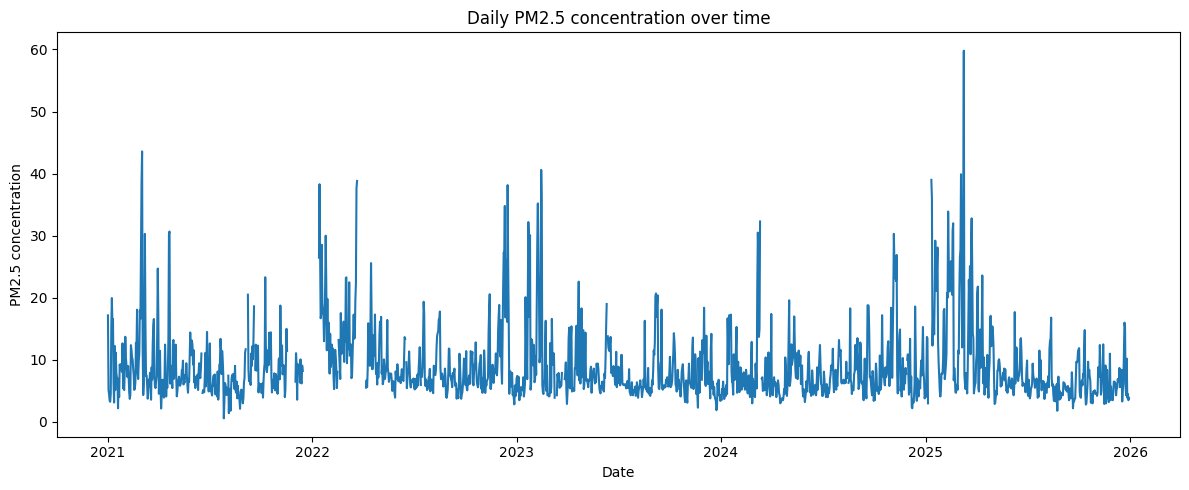

Saved: /content/outputs/figures/daily_pm25_time_series.png


In [31]:
import matplotlib.pyplot as plt

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Use PM2.5 column for plotting
plot_col = "pm25_raw"

# 1. Raw PM2.5 time-series graph
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df[plot_col])
plt.title("Daily PM2.5 concentration over time")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.tight_layout()

time_series_path = FIGURE_DIR / "daily_pm25_time_series.png"
plt.savefig(time_series_path, dpi=300)
plt.show()

print("Saved:", time_series_path)

PM2.5 with Rolling Mean Trend

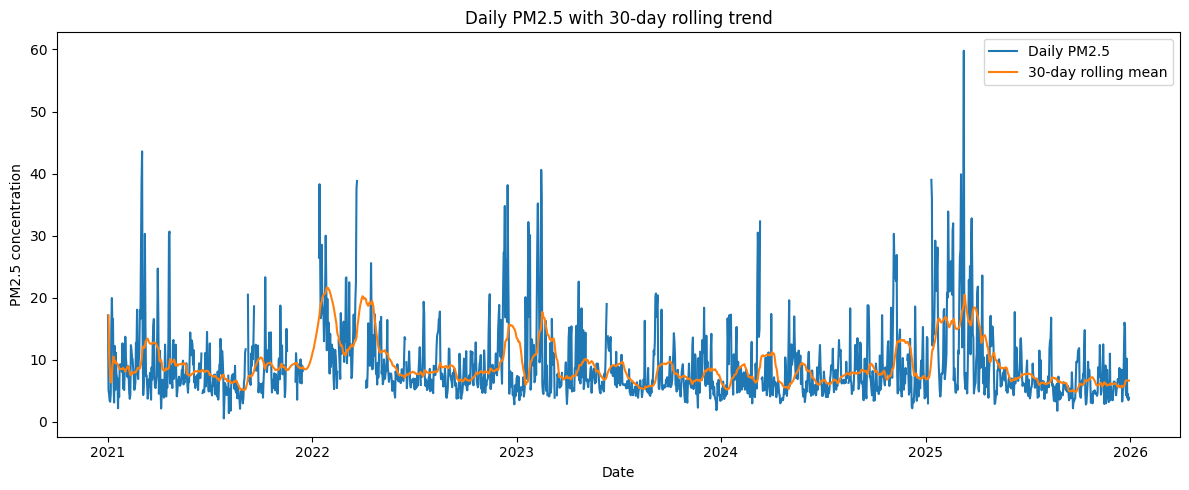

Saved: /content/outputs/figures/pm25_30_day_rolling_trend.png


In [35]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["pm25_raw"], label="Daily PM2.5")
plt.plot(df["date"], df["pm25_roll_mean_30d"], label="30-day rolling mean")
plt.title("Daily PM2.5 with 30-day rolling trend")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.legend()
plt.tight_layout()

rolling_trend_path = FIGURE_DIR / "pm25_30_day_rolling_trend.png"
plt.savefig(rolling_trend_path, dpi=300)
plt.show()

print("Saved:", rolling_trend_path)



Monthly Average PM2.5 Trend


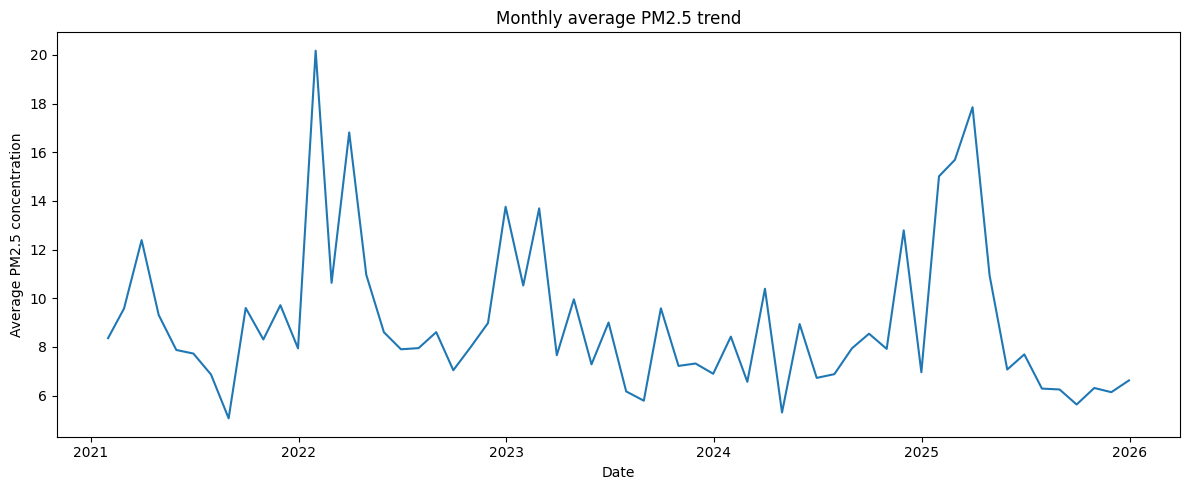

Saved: /content/outputs/figures/monthly_average_pm25_trend.png


In [36]:
monthly_pm25 = (
    df.set_index("date")["pm25_raw"]
    .resample("M")
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_pm25["date"], monthly_pm25["pm25_raw"])
plt.title("Monthly average PM2.5 trend")
plt.xlabel("Date")
plt.ylabel("Average PM2.5 concentration")
plt.tight_layout()

monthly_trend_path = FIGURE_DIR / "monthly_average_pm25_trend.png"
plt.savefig(monthly_trend_path, dpi=300)
plt.show()

print("Saved:", monthly_trend_path)


Missing PM2.5 Values by Year

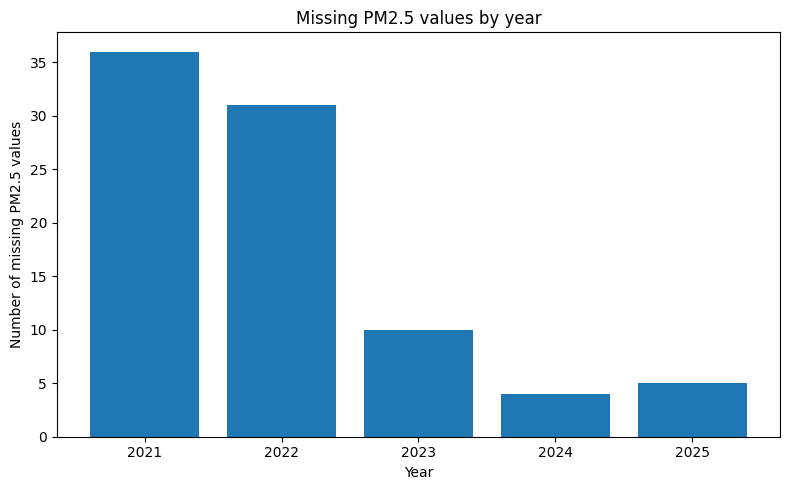

Saved: /content/outputs/figures/missing_pm25_values_by_year.png


In [37]:
missing_by_year = (
    df.groupby("year")["pm25_missing_flag"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(missing_by_year["year"].astype(str), missing_by_year["pm25_missing_flag"])
plt.title("Missing PM2.5 values by year")
plt.xlabel("Year")
plt.ylabel("Number of missing PM2.5 values")
plt.tight_layout()

missing_year_path = FIGURE_DIR / "missing_pm25_values_by_year.png"
plt.savefig(missing_year_path, dpi=300)
plt.show()

print("Saved:", missing_year_path)

2.12. Final Feature Summary and Save Outputs

Output files


The final engineered dataset is saved to the GitHub project folder under data/features/. This output can be used by the modelling team for PM2.5 forecasting.

The final dataset includes raw PM2.5 values, missing-value flags, time-based attributes, lag features, rolling trend features, rate-of-change features, seasonal cyclical features, and peer-station availability indicators.

In [39]:
# =========================================================
# Final feature summary and save outputs
# =========================================================

feature_cols = [
    col for col in df.columns
    if col.startswith("pm25_lag_")
    or col.startswith("pm25_roll_")
    or col.startswith("pm25_diff_")
    or col.startswith("pm25_rate_change_")
    or col.startswith("peer_pm25_")
    or col in [
        "month_sin",
        "month_cos",
        "day_of_year_sin",
        "day_of_year_cos",
        "pm25_missing_flag"
    ]
]

print("Number of engineered features:", len(feature_cols))
print("\nFeature columns:")
for col in feature_cols:
    print("-", col)

feature_output_path = FEATURE_OUTPUT_DIR / "pm25_complete_engineered_features.csv"
peer_selection_output_path = FEATURE_OUTPUT_DIR / "pm25_dtw_peer_station_selection.csv"

df.to_csv(feature_output_path, index=False)

if len(peer_station_df) > 0:
    peer_station_df.to_csv(peer_selection_output_path, index=False)

print("\nSaved complete feature dataset to:")
print(feature_output_path)

if len(peer_station_df) > 0:
    print("\nSaved peer-station DTW selection to:")
    print(peer_selection_output_path)

print("\nFinal dataset shape:", df.shape)

df.head(10)

Number of engineered features: 55

Feature columns:
- pm25_missing_flag
- pm25_lag_1d
- pm25_lag_2d
- pm25_lag_3d
- pm25_lag_6d
- pm25_lag_7d
- pm25_lag_12d
- pm25_lag_14d
- pm25_lag_30d
- pm25_roll_mean_3d
- pm25_roll_std_3d
- pm25_roll_min_3d
- pm25_roll_max_3d
- pm25_roll_range_3d
- pm25_roll_mean_6d
- pm25_roll_std_6d
- pm25_roll_min_6d
- pm25_roll_max_6d
- pm25_roll_range_6d
- pm25_roll_mean_7d
- pm25_roll_std_7d
- pm25_roll_min_7d
- pm25_roll_max_7d
- pm25_roll_range_7d
- pm25_roll_mean_12d
- pm25_roll_std_12d
- pm25_roll_min_12d
- pm25_roll_max_12d
- pm25_roll_range_12d
- pm25_roll_mean_14d
- pm25_roll_std_14d
- pm25_roll_min_14d
- pm25_roll_max_14d
- pm25_roll_range_14d
- pm25_roll_mean_30d
- pm25_roll_std_30d
- pm25_roll_min_30d
- pm25_roll_max_30d
- pm25_roll_range_30d
- pm25_diff_1d
- pm25_rate_change_1d
- pm25_diff_3d
- pm25_rate_change_3d
- pm25_diff_6d
- pm25_rate_change_6d
- pm25_diff_7d
- pm25_rate_change_7d
- pm25_diff_12d
- pm25_rate_change_12d
- pm25_diff_14d
- pm25_

,date,station,date_raw,pm25_raw,status_raw,source_file,pm25_missing_flag,year,month,day,...,pm25_diff_12d,pm25_rate_change_12d,pm25_diff_14d,pm25_rate_change_14d,month_sin,month_cos,day_of_year_sin,day_of_year_cos,peer_feature_available,peer_feature_note
0,2021-01-01,London Marylebone Road,2021-01-01,17.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,1,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.017202,0.999852,False,Not available: single-station dataset.
1,2021-01-02,London Marylebone Road,2021-01-02,5.167,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,2,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.034398,0.999408,False,Not available: single-station dataset.
2,2021-01-03,London Marylebone Road,2021-01-03,4.500,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,3,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.051584,0.998669,False,Not available: single-station dataset.
3,2021-01-04,London Marylebone Road,2021-01-04,3.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,4,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.068755,0.997634,False,Not available: single-station dataset.
4,2021-01-05,London Marylebone Road,2021-01-05,3.250,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,5,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.085906,0.996303,False,Not available: single-station dataset.
5,2021-01-06,London Marylebone Road,2021-01-06,4.542,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,6,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.103031,0.994678,False,Not available: single-station dataset.
6,2021-01-07,London Marylebone Road,2021-01-07,15.333,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,7,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.120126,0.992759,False,Not available: single-station dataset.
7,2021-01-08,London Marylebone Road,2021-01-08,19.958,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,8,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.137185,0.990545,False,Not available: single-station dataset.
8,2021-01-09,London Marylebone Road,2021-01-09,15.458,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,9,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.154204,0.988039,False,Not available: single-station dataset.
9,2021-01-10,London Marylebone Road,2021-01-10,16.583,V ugm-3 (GRAV EMFAB),PM2.5_AirQualityDataDaily_2021-2025.csv,0,2021,1,10,...,NaN,NaN,NaN,NaN,0.5,0.866025,0.171177,0.985240,False,Not available: single-station dataset.


Summary of PM2.5 Feature Engineering

This notebook completes the feature engineering process for PM2.5 air quality data at London Marylebone Road, covering 2021 to 2025.

Task 1 — Historical PM2.5 Data and Trend Attributes

The first phase focused on building a foundational set of time series features from the raw PM2.5 data. This included loading and cleaning the data, ensuring a continuous daily time index and filling small gaps using interpolation. From there, lag features were generated to capture the direct influence of past PM2.5 values, alongside rolling statistics such as means, standard deviations, minimums and maximums over windows of 3, 7, 14 and 30 days. Rate of change features were also derived to capture how quickly PM2.5 levels were rising or falling. Seasonal decomposition was applied to extract the underlying trend, seasonal and residual components from the series. A set of 15 trend attributes was implemented based on the Wood (2024) univariate approach, covering rolling averages, differences, rates, volatility and ratios. Finally, cyclical sine and cosine encodings were added for day of year, day of week and day of month, and all features were evaluated against next-day PM2.5 to identify the strongest predictors.

Task 2 — Refined and Expanded Historical Features

The second phase built on Task 1 with more robust data preparation and a more comprehensive feature set. A dedicated interpolated PM2.5 column was created for feature generation to avoid any leakage from the target variable. Lag and rolling features were regenerated with additional windows, and rate of change features were extended across more time periods. Explicit timestamp components including year, month, day, day of year, day of week and quarter were added, along with seasonal cyclical encodings for month and day of year. The notebook also included logic for spatiotemporal peer station features using Dynamic Time Warping, however since the dataset contains only a single monitoring station these features were not generated. The notebook correctly identified this limitation and continued without attempting to create them.

Final Output

All applicable features from both tasks were consolidated into a single dataframe and saved as pm25_complete_engineered_features.csv. The final dataset has a shape of 1825 rows and 70 columns, representing the original data enriched with 55 engineered features, ready for model training.

# Task 3 — Auxiliary Air Pollutants and Chemical Compounds
This notebook loads, cleans and merges all auxiliary pollutant data for London Marylebone Road (2021–2025).

Pollutants covered:

O3 — Ozone
NO — Nitric Oxide
NO2 — Nitrogen Dioxide
NOx — Nitrogen Oxides
PM10 — Particulate Matter (daily)
Files needed (upload to /content/):

NO2, NO, O3_2021-2025.csv
(NOx)2021-2025.csv
Carbon monoxide_2021-2025.csv
PM10_AirQualityDataDaily_2021-2025.csv
0. Imports
This section imports all necessary Python libraries for data loading, manipulation, and visualization, ensuring the environment is set up for the subsequent analysis steps.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


1. Helper Functions
This section defines helper functions designed to streamline the process of loading air quality data from various CSV file formats provided by DEFRA. These functions parse, clean, and standardize the data into a consistent daily mean format, handling both single and multi-pollutant hourly files, as well as single pollutant daily files.

In [41]:
def load_hourly_single(filepath, col_name, skip=11):
    """
    Load a DEFRA hourly CSV with one pollutant column.
    Returns daily mean dataframe with columns: date, col_name
    """
    raw = pd.read_csv(filepath, skiprows=skip, header=None,
                      usecols=[0, 1, 2], names=['date', 'time', col_name])
    raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
    raw[col_name] = pd.to_numeric(raw[col_name], errors='coerce')
    raw = raw.dropna(subset=['date'])
    # Aggregate hourly to daily mean
    daily = raw.groupby('date')[col_name].mean().reset_index()
    return daily


def load_hourly_multi(filepath, col_map, skip=18):
    """
    Load a DEFRA hourly CSV with multiple pollutant columns.
    col_map: dict of {column_index: new_name} e.g. {2: 'O3', 4: 'NO', 6: 'NO2'}
    Returns daily mean dataframe.
    """
    usecols = [0] + list(col_map.keys())
    col_names = ['date'] + list(col_map.values())
    raw = pd.read_csv(filepath, skiprows=skip, header=None,
                      usecols=usecols)
    raw.columns = col_names
    raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
    raw = raw.dropna(subset=['date'])
    for col in col_map.values():
        raw[col] = pd.to_numeric(raw[col], errors='coerce')
    daily = raw.groupby('date')[list(col_map.values())].mean().reset_index()
    return daily


def load_daily_single(filepath, col_name, skip=10):
    """
    Load a DEFRA daily CSV with one pollutant column.
    Returns dataframe with columns: date, col_name
    """
    raw = pd.read_csv(filepath, skiprows=skip, header=None,
                      usecols=[0, 1], names=['date', col_name])
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw[col_name] = pd.to_numeric(raw[col_name], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw


def combine_files(df1, df2, on='date'):
    """
    Stack two dataframes and sort by date.
    """
    combined = pd.concat([df1, df2], ignore_index=True)
    combined = combined.sort_values(on).drop_duplicates(on).reset_index(drop=True)
    return combined


print('Helper functions defined!')

Helper functions defined!


2. Load O3, NO, NO2
This section loads data for Ozone (O3), Nitric Oxide (NO), and Nitrogen Dioxide (NO2) from the provided multi-pollutant hourly CSV files. It combines data from different periods into a single, comprehensive dataset for these pollutants.

O3 (Ozone): A secondary pollutant formed from reactions between sunlight and emissions from vehicles and industrial sources. While ozone in the upper atmosphere protects Earth from harmful UV radiation, ground-level ozone is a harmful air pollutant that can cause respiratory problems.
NO (Nitric Oxide): A primary pollutant produced during combustion processes, primarily from vehicle engines and power plants. NO reacts quickly with ozone and other atmospheric components to form nitrogen dioxide.
NO2 (Nitrogen Dioxide): A primary pollutant emitted from combustion, contributing to respiratory issues, acid rain, and the formation of ground-level ozone and particulate matter.

In [42]:
# Column mapping: col index -> pollutant name
# Format: Date, Time, O3, Status, NO, Status, NO2, Status
col_map = {2: 'O3', 4: 'NO', 6: 'NO2'}

print('Loading NO2/NO/O3 2021-2025...')
df_no2_no_o3 = load_hourly_multi('/content/NO2, NO, O3_2021-2025.csv', col_map, skip=18)
print(f'  Shape: {df_no2_no_o3.shape}, Date range: {df_no2_no_o3["date"].min().date()} to {df_no2_no_o3["date"].max().date()}')

print(f'\nLoaded NO2/NO/O3 shape: {df_no2_no_o3.shape}')
df_no2_no_o3.head()

Loading NO2/NO/O3 2021-2025...
  Shape: (1825, 4), Date range: 2021-01-01 to 2025-12-30

Loaded NO2/NO/O3 shape: (1825, 4)


,date,O3,NO,NO2
0,2021-01-01,14.168778,21.136486,29.890934
1,2021-01-02,21.778473,11.243936,24.353095
2,2021-01-03,25.285105,6.264511,16.727747
3,2021-01-04,35.145802,3.982668,13.439898
4,2021-01-05,29.900160,6.389799,15.996390


3. Load NOx (Nitrogen Oxides)
This section loads data specifically for Nitrogen Oxides (NOx), which is a collective term for Nitric Oxide (NO) and Nitrogen Dioxide (NO2). NOx pollutants are primarily emitted from the burning of fossil fuels and are significant contributors to smog, acid rain, and various respiratory diseases.

In [43]:
print('Loading NOx 2021-2025...')
df_nox = load_hourly_single('/content/(NOx)2021-2025.csv', 'NOx', skip=11)
print(f'  Shape: {df_nox.shape}, Date range: {df_nox["date"].min().date()} to {df_nox["date"].max().date()}')

print(f'\nLoaded NOx shape: {df_nox.shape}')
df_nox.head()

Loading NOx 2021-2025...
  Shape: (1825, 2), Date range: 2021-01-01 to 2025-12-30

Loaded NOx shape: (1825, 2)


,date,NOx
0,2021-01-01,62.299762
1,2021-01-02,41.593555
2,2021-01-03,26.333197
3,2021-01-04,19.546571
4,2021-01-05,25.793945


4. Load CO (Carbon Monoxide)
This section loads data for Carbon Monoxide (CO), a colorless, odorless, and poisonous gas formed when carbon-containing fuels are burned incompletely. It is a major component of vehicle exhaust and can reduce oxygen delivery to the body's organs and tissues, posing serious health risks.

In [44]:
print('Loading CO 2021-2025...')
df_co = load_hourly_single('/content/Carbon monoxide_2021-2025.csv', 'CO', skip=11) # Loading the file named for 2021-2025, which we found contains 2016-2020 data.
print(f'  Shape: {df_co.shape}, Date range: {df_co["date"].min().date()} to {df_co["date"].max().date()}')

print(f'\nLoaded CO shape: {df_co.shape}')
df_co.head()

Loading CO 2021-2025...
  Shape: (1825, 2), Date range: 2021-01-01 to 2025-12-30

Loaded CO shape: (1825, 2)


,date,CO
0,2021-01-01,0.330584
1,2021-01-02,0.243317
2,2021-01-03,0.120144
3,2021-01-04,0.132458
4,2021-01-05,0.098882


5. Load PM10 (Daily)
This section loads data for Particulate Matter with a diameter of 10 micrometers or less (PM10). These fine inhalable particles are emitted from various sources, including vehicle exhaust, industrial processes, and construction, and are small enough to penetrate deep into the lungs, causing respiratory and cardiovascular problems.

In [45]:
print('Loading PM10 2021-2025...')
df_pm10 = load_daily_single('/content/PM10_AirQualityDataDaily_2021-2025.csv', 'PM10', skip=10)
print(f'  Shape: {df_pm10.shape}, Date range: {df_pm10["date"].min().date()} to {df_pm10["date"].max().date()}')

print(f'\nLoaded PM10 shape: {df_pm10.shape}')
df_pm10.head()

Loading PM10 2021-2025...
  Shape: (1641, 2), Date range: 2021-01-01 to 2025-12-30

Loaded PM10 shape: (1641, 2)


,date,PM10
1,2021-01-01,21.254
2,2021-01-02,7.629
3,2021-01-03,7.838
4,2021-01-04,7.171
5,2021-01-05,7.671


6. Merge All Pollutants Together
This section consolidates all individual pollutant datasets (O3, NO, NO2, NOx, CO, and PM10) into a single, unified DataFrame. The merging is performed based on the 'date' column, ensuring that all pollutant concentrations correspond to the correct day and are associated with the 'London Marylebone Road' station.

In [46]:
# Start with NO2/NO/O3 as base
df = df_no2_no_o3.copy()

# Merge each pollutant
for name, df_poll in [('NOx', df_nox), ('CO', df_co), ('PM10', df_pm10)]:
    df = df.merge(df_poll, on='date', how='outer')
    print(f'After merging {name}: {df.shape}')

df = df.sort_values('date').drop_duplicates(subset=['date']).reset_index(drop=True)
df['station'] = 'London Marylebone Road'

# Filter the merged DataFrame to the intended 2021-2025 date range
df = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2025-12-31')].copy()

print(f'\nFinal merged shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

After merging NOx: (1825, 5)
After merging CO: (1825, 6)
After merging PM10: (1825, 7)

Final merged shape: (1825, 8)
Date range: 2021-01-01 to 2025-12-30
Columns: ['date', 'O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10', 'station']


,date,O3,NO,NO2,NOx,CO,PM10,station
0,2021-01-01,14.168778,21.136486,29.890934,62.299762,0.330584,21.254,London Marylebone Road
1,2021-01-02,21.778473,11.243936,24.353095,41.593555,0.243317,7.629,London Marylebone Road
2,2021-01-03,25.285105,6.264511,16.727747,26.333197,0.120144,7.838,London Marylebone Road
3,2021-01-04,35.145802,3.982668,13.439898,19.546571,0.132458,7.171,London Marylebone Road
4,2021-01-05,29.900160,6.389799,15.996390,25.793945,0.098882,7.671,London Marylebone Road
5,2021-01-06,19.011815,10.700646,22.537950,38.945375,0.188764,10.129,London Marylebone Road
6,2021-01-07,7.240650,54.855488,46.880852,130.991428,0.344151,25.379,London Marylebone Road
7,2021-01-08,4.689203,40.403775,40.755507,102.707097,0.275775,NaN,London Marylebone Road
8,2021-01-09,12.358095,40.673463,41.303107,103.668214,0.407433,20.296,London Marylebone Road
9,2021-01-10,10.437234,31.936142,40.604658,89.572725,0.235084,17.796,London Marylebone Road


7. Missing Value Summary
This section provides a summary of missing values for each pollutant in the merged dataset. It quantifies the number and percentage of missing entries, offering insights into data completeness and potential areas requiring imputation or careful consideration during analysis.

In [47]:
pollutants = ['O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10']

print('--- Missing Values Per Pollutant ---')
for p in pollutants:
    if p in df.columns:
        missing = df[p].isna().sum()
        total = len(df)
        print(f'  {p:<6}: {missing:>5} missing ({missing/total*100:.1f}%)')

print(f'\nTotal records: {len(df):,}')
print(f'Total days expected (2021-2025): {(pd.Timestamp("2025-12-31") - pd.Timestamp("2021-01-01")).days + 1}')

--- Missing Values Per Pollutant ---
  O3    :    30 missing (1.6%)
  NO    :    36 missing (2.0%)
  NO2   :    36 missing (2.0%)
  NOx   :    36 missing (2.0%)
  CO    :   202 missing (11.1%)
  PM10  :   382 missing (20.9%)

Total records: 1,825
Total days expected (2021-2025): 1826


8. Visualisations
This section focuses on visualizing the processed pollutant data to identify trends, patterns, and relationships. It includes time series plots for individual pollutants, a correlation heatmap to show inter-pollutant relationships, monthly seasonal patterns, and boxplots for distribution comparison, along with an analysis of COVID-19 lockdown impact.

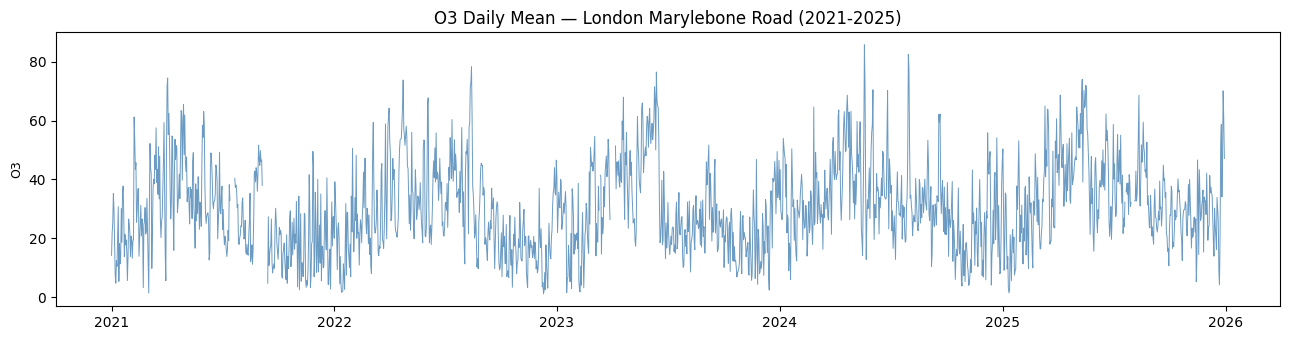

Saved: auxiliary_pollutant_o3_timeseries_2021_2025.png


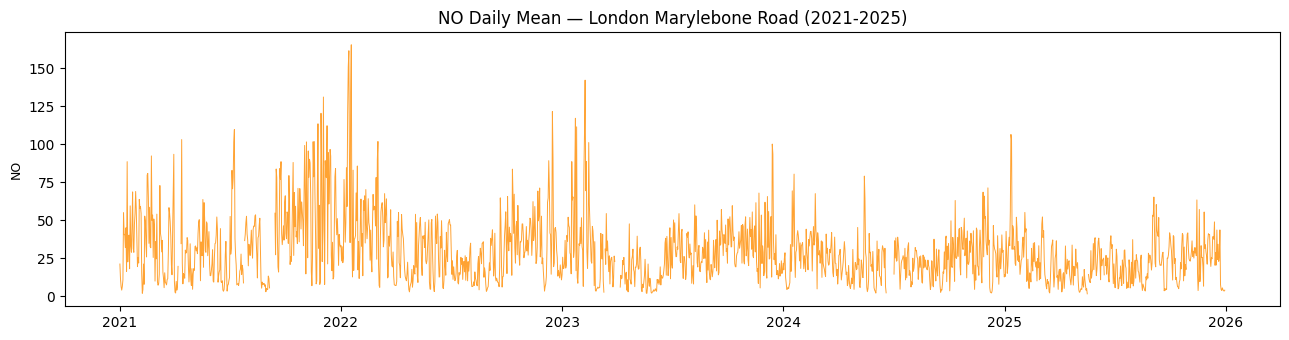

Saved: auxiliary_pollutant_no_timeseries_2021_2025.png


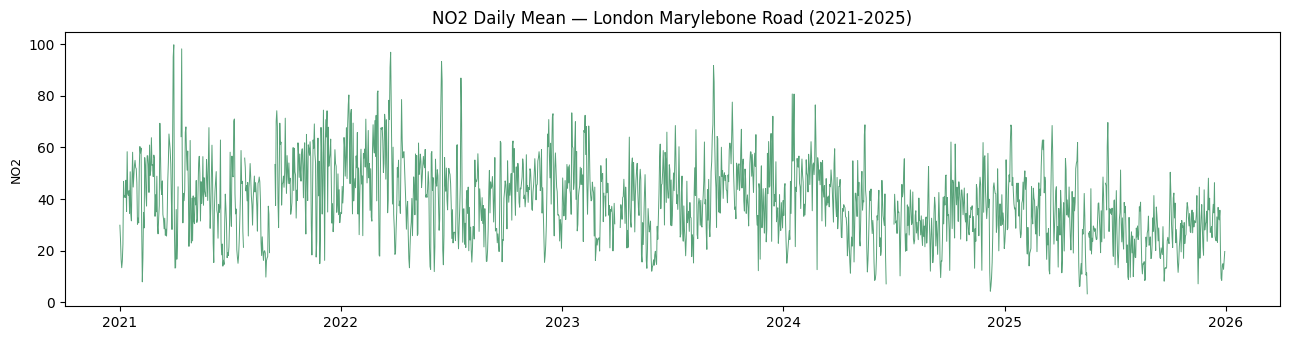

Saved: auxiliary_pollutant_no2_timeseries_2021_2025.png


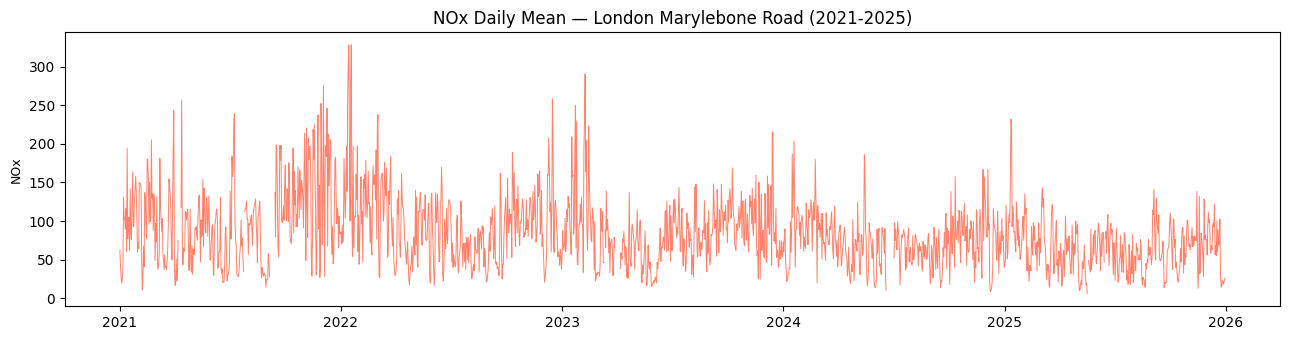

Saved: auxiliary_pollutant_nox_timeseries_2021_2025.png


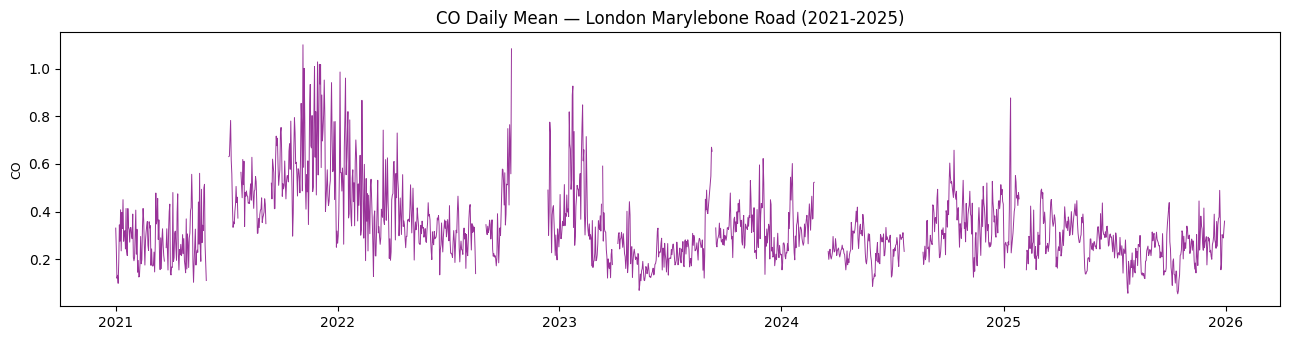

Saved: auxiliary_pollutant_co_timeseries_2021_2025.png


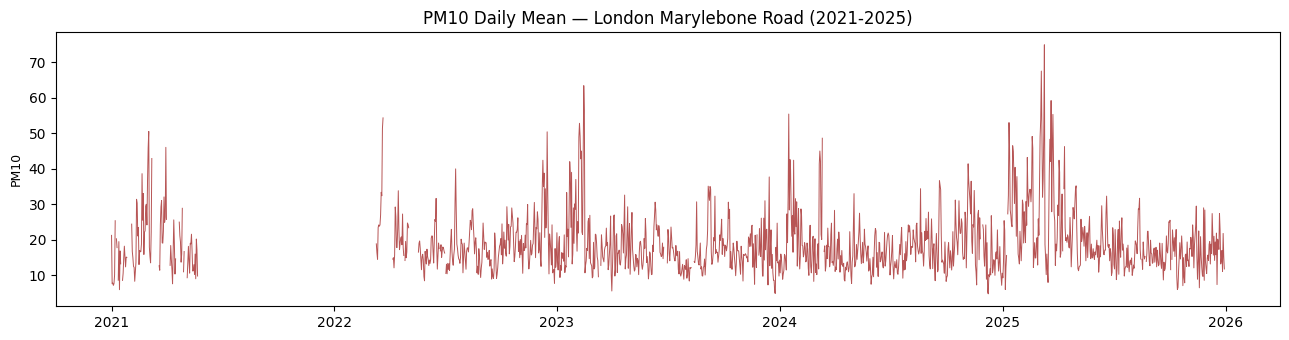

Saved: auxiliary_pollutant_pm10_timeseries_2021_2025.png


In [48]:
# Define pollutants and available at the start of the visualization section for robustness
pollutants = ['O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10']
available = [p for p in pollutants if p in df.columns]

# Plot 1: Time series for each pollutant
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple', 'brown']

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(13, 3.5)) # Create a new figure for each plot
    ax.plot(df['date'], df[p], linewidth=0.7, color=c, alpha=0.8)
    ax.set_ylabel(p, fontsize=9)
    ax.set_title(f'{p} Daily Mean — London Marylebone Road (2021-2025)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_timeseries_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_timeseries_2021_2025.png')

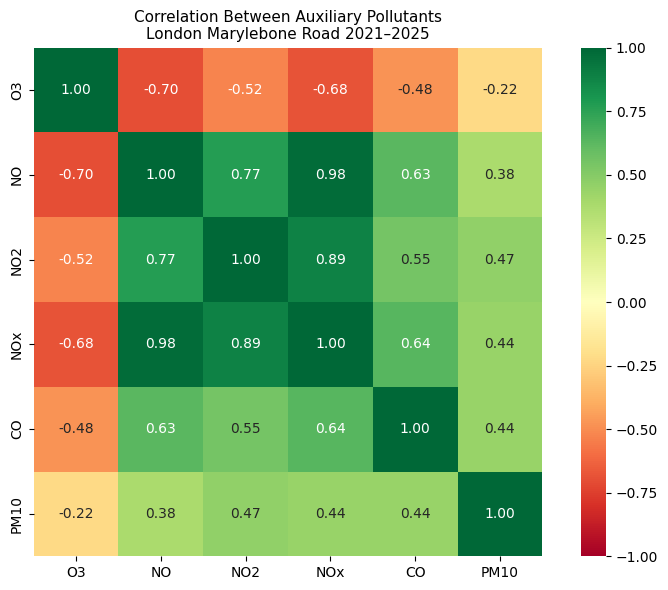

Saved: auxiliary_pollutants_correlation_2021_2025.png


In [49]:
# Plot 2: Correlation heatmap between pollutants
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Between Auxiliary Pollutants\nLondon Marylebone Road 2021–2025', fontsize=11)
plt.tight_layout()
plt.savefig('auxiliary_pollutants_correlation_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: auxiliary_pollutants_correlation_2021_2025.png')

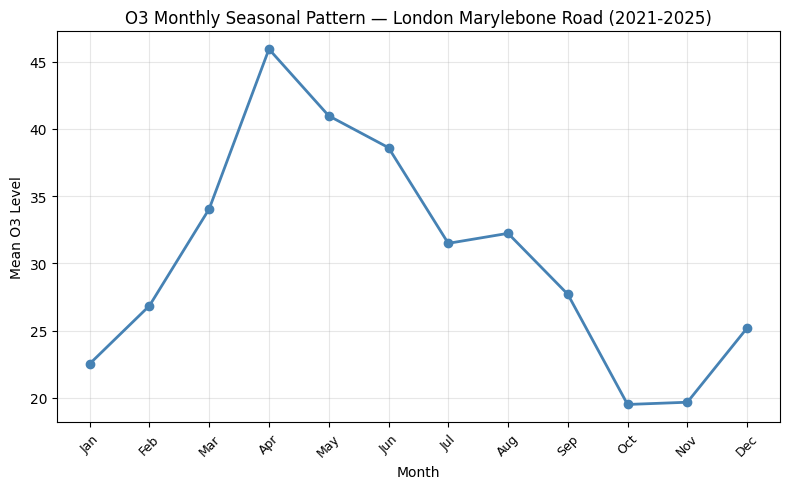

Saved: auxiliary_pollutant_o3_seasonal_2021_2025.png


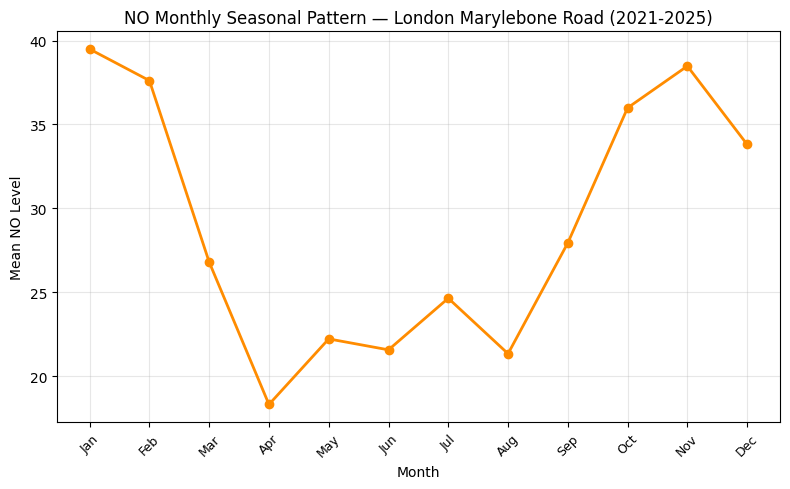

Saved: auxiliary_pollutant_no_seasonal_2021_2025.png


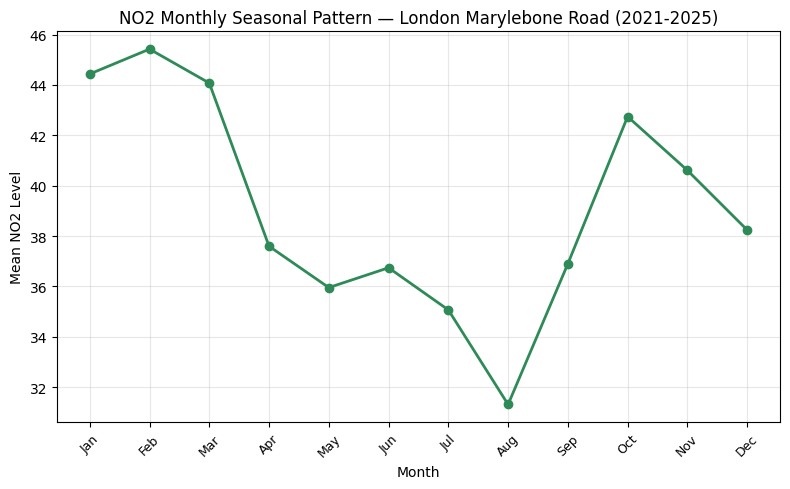

Saved: auxiliary_pollutant_no2_seasonal_2021_2025.png


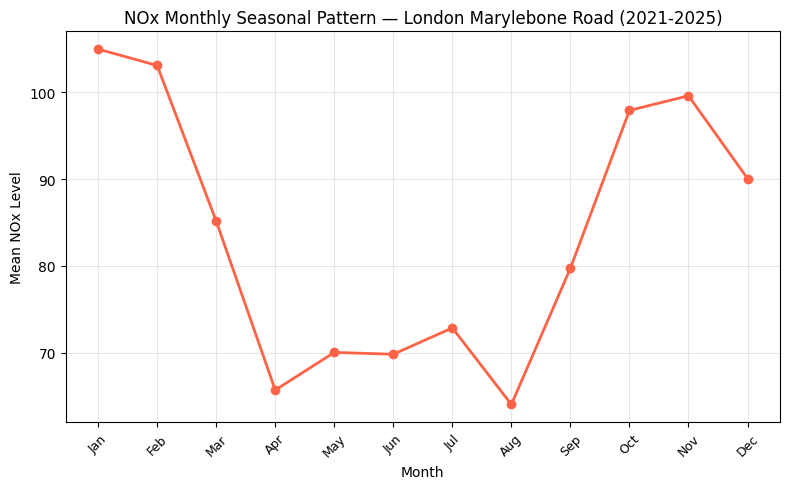

Saved: auxiliary_pollutant_nox_seasonal_2021_2025.png


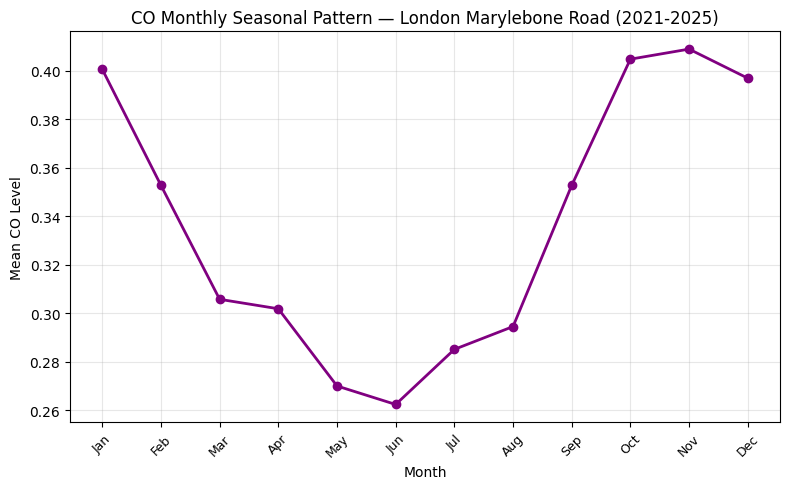

Saved: auxiliary_pollutant_co_seasonal_2021_2025.png


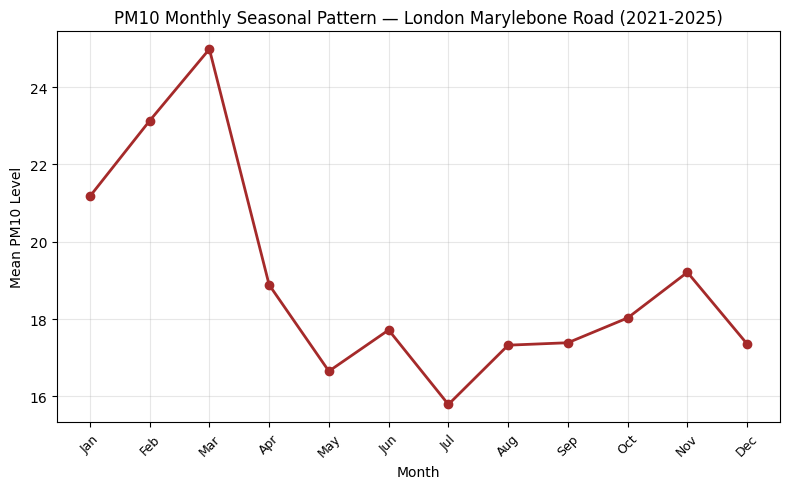

Saved: auxiliary_pollutant_pm10_seasonal_2021_2025.png


In [51]:
# Plot 3: Monthly seasonal patterns for each pollutant
df['month'] = df['date'].dt.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(8, 5)) # Create a new figure for each plot
    monthly = df.groupby('month')[p].mean()
    ax.plot(monthly.index, monthly.values, marker='o', color=c, linewidth=2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9, rotation=45)
    ax.set_title(f'{p} Monthly Seasonal Pattern — London Marylebone Road (2021-2025)', fontsize=12)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel(f'Mean {p} Level', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_seasonal_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_seasonal_2021_2025.png')

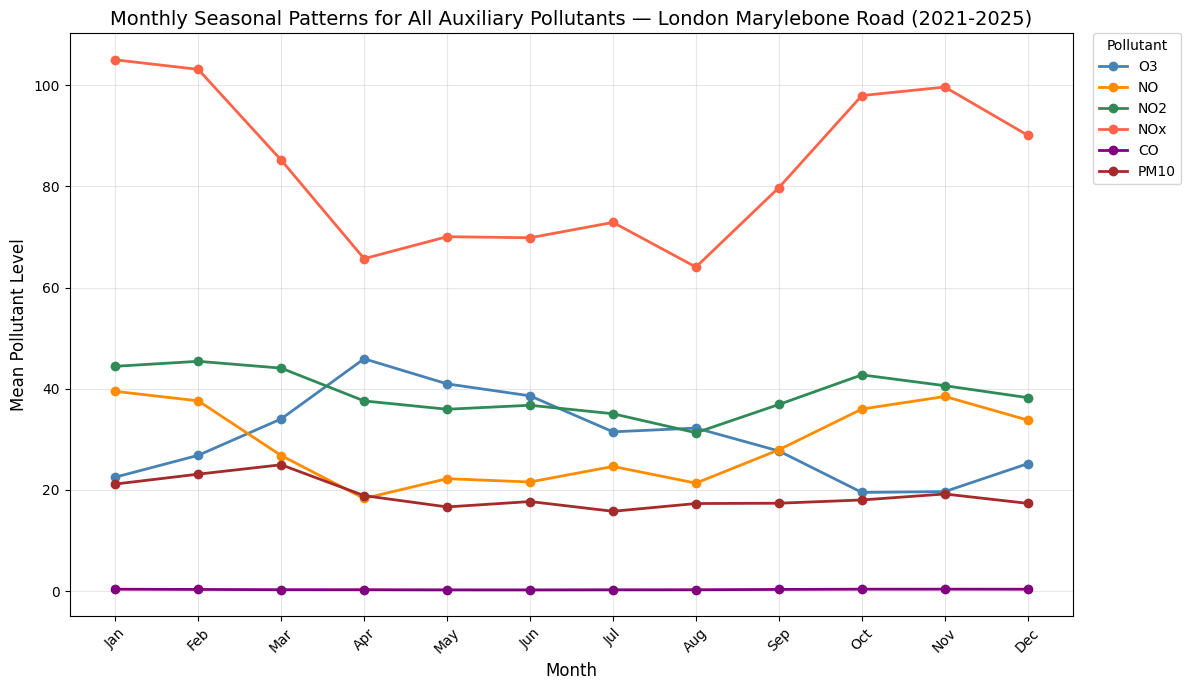

Saved: auxiliary_pollutants_all_seasonal_combined_2021_2025.png


In [52]:
# Plot 5: Monthly seasonal patterns for all pollutants on a single graph

# Calculate monthly means for all available pollutants
monthly_all_pollutants = df.groupby('month')[available].mean()

fig, ax = plt.subplots(figsize=(12, 7))

# Plot each pollutant's monthly seasonal pattern
for i, p in enumerate(available):
    ax.plot(monthly_all_pollutants.index, monthly_all_pollutants[p], marker='o', linewidth=2, label=p, color=colors[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=10, rotation=45)
ax.set_title('Monthly Seasonal Patterns for All Auxiliary Pollutants — London Marylebone Road (2021-2025)', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean Pollutant Level', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title='Pollutant', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig('auxiliary_pollutants_all_seasonal_combined_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: auxiliary_pollutants_all_seasonal_combined_2021_2025.png')

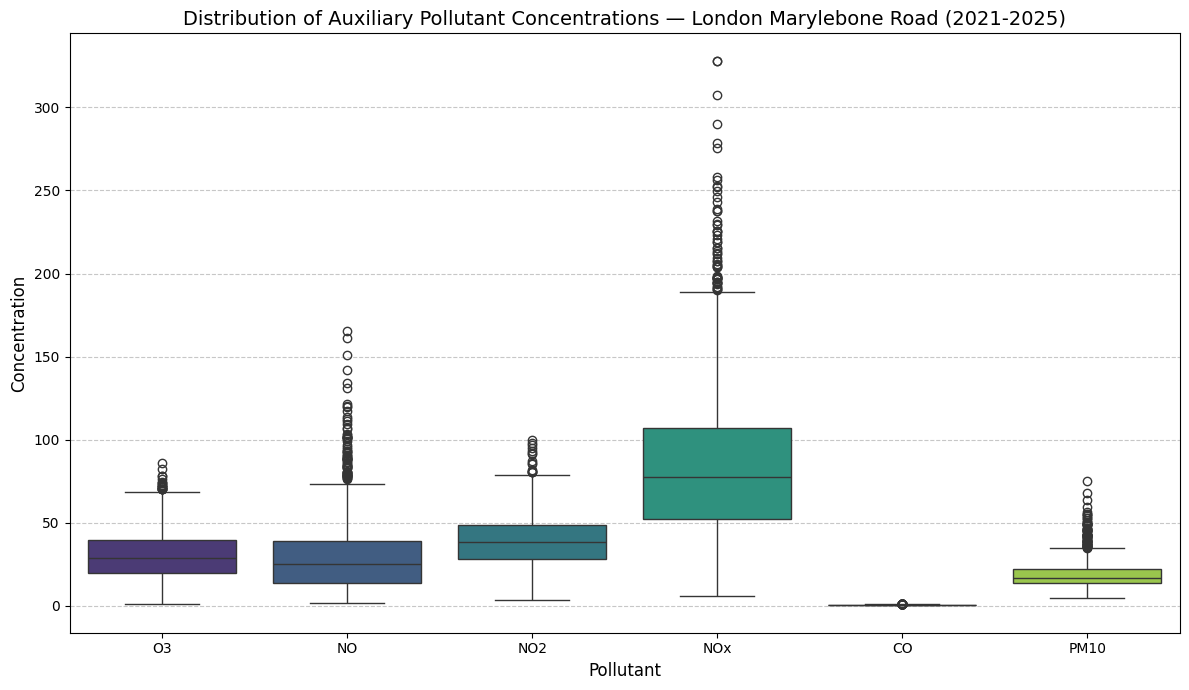

Saved: auxiliary_pollutants_boxplot_distribution_2021_2025.png


In [53]:
# Plot 6: Boxplots to compare the distribution of pollutant values

# Prepare data for boxplot: unpivot the DataFrame to long format
df_melted = df.melt(id_vars=['date', 'station'], value_vars=available, var_name='Pollutant', value_name='Concentration')

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(x='Pollutant', y='Concentration', data=df_melted, palette='viridis', ax=ax)
ax.set_title('Distribution of Auxiliary Pollutant Concentrations — London Marylebone Road (2021-2025)', fontsize=14)
ax.set_xlabel('Pollutant', fontsize=12)
ax.set_ylabel('Concentration', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('auxiliary_pollutants_boxplot_distribution_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: auxiliary_pollutants_boxplot_distribution_2021_2025.png')

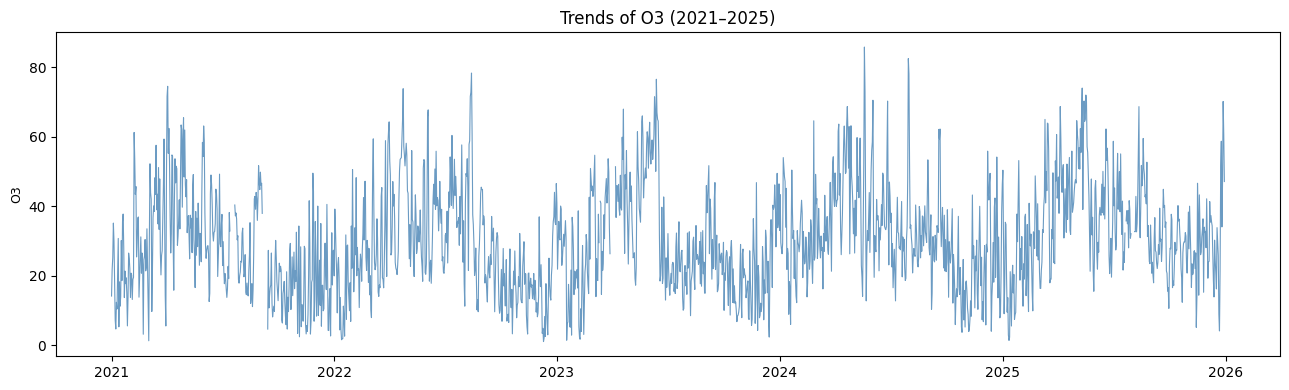

Saved: auxiliary_pollutant_o3_trends_2021_2025.png


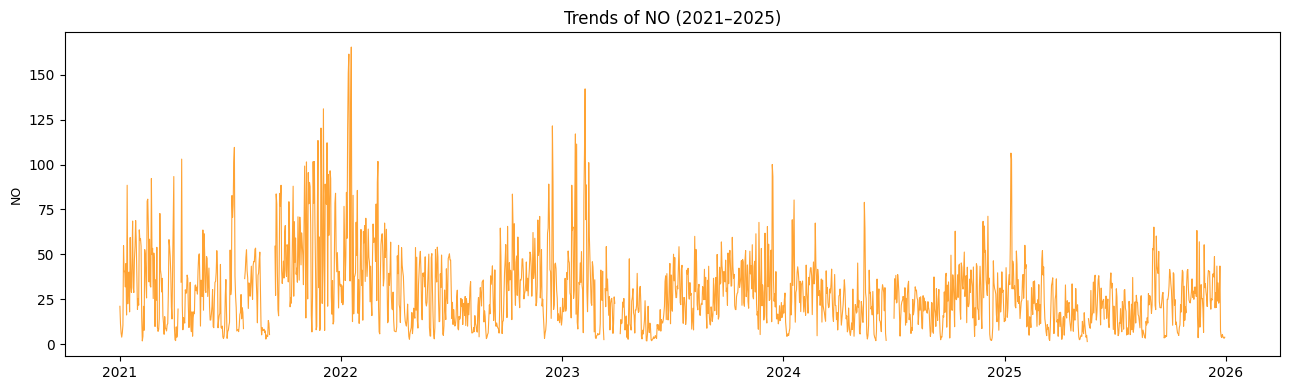

Saved: auxiliary_pollutant_no_trends_2021_2025.png


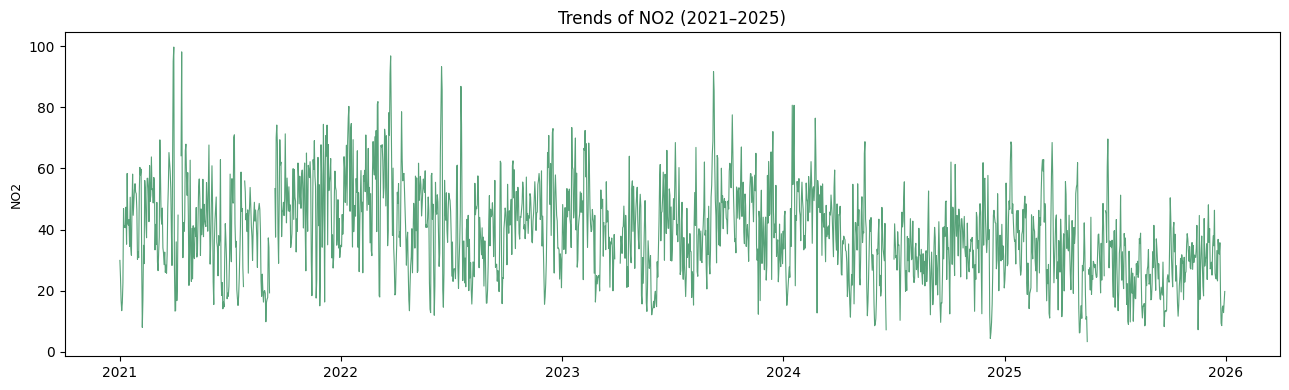

Saved: auxiliary_pollutant_no2_trends_2021_2025.png


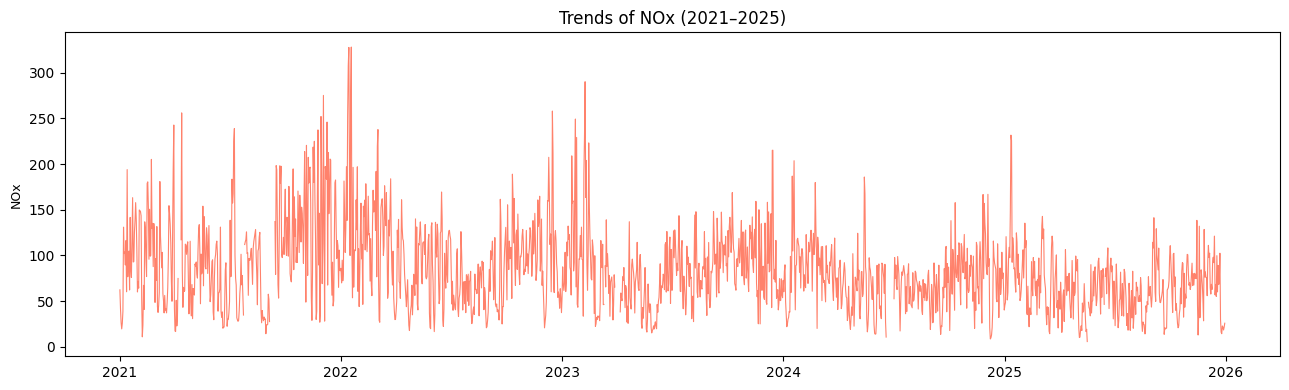

Saved: auxiliary_pollutant_nox_trends_2021_2025.png


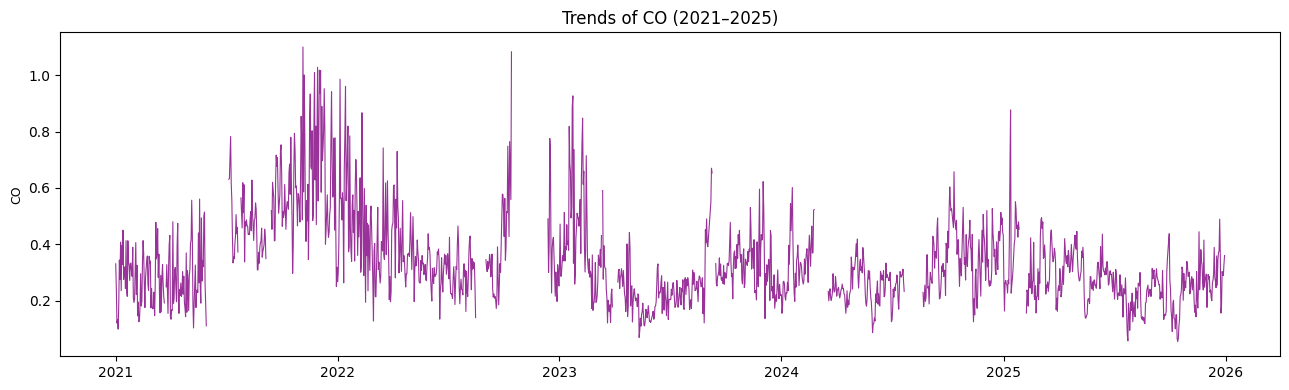

Saved: auxiliary_pollutant_co_trends_2021_2025.png


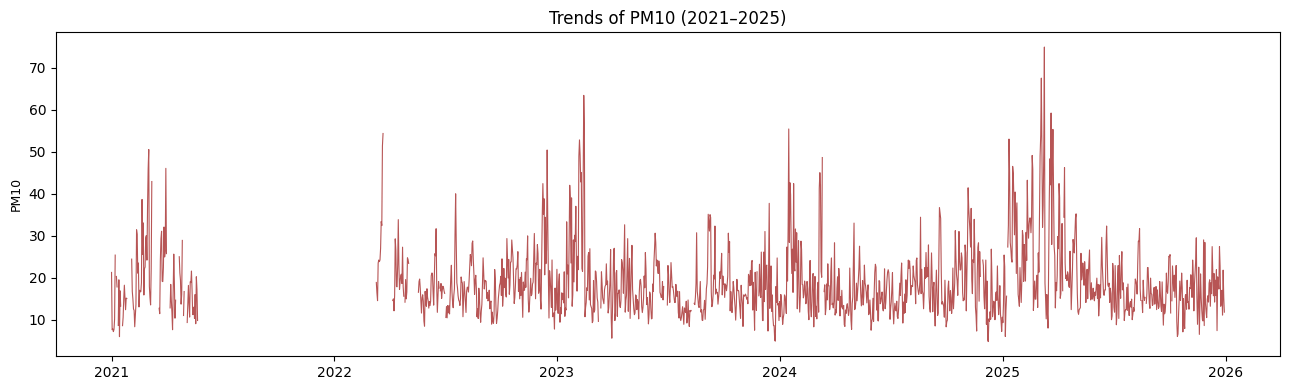

Saved: auxiliary_pollutant_pm10_trends_2021_2025.png


In [54]:
# Plot 4: Analyze trends during the 2021-2025 period
# Note: The original COVID-19 lockdown period (2020) is not covered by the current data (2021-2025).
# This plot now focuses on general trends within the 2021-2025 range.

zoom_data = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2025-12-31')].copy()

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(13, 4)) # Create a new figure for each plot
    ax.plot(zoom_data['date'], zoom_data[p], linewidth=0.8, color=c, alpha=0.8)
    ax.set_ylabel(p, fontsize=9)
    ax.set_title(f'Trends of {p} (2021–2025)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_trends_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_trends_2021_2025.png')

Day of Week Patterns
This visualization examines how pollutant concentrations vary on different days of the week, helping to identify weekly cycles or trends that might be influenced by human activities (e.g., traffic patterns, industrial operations).

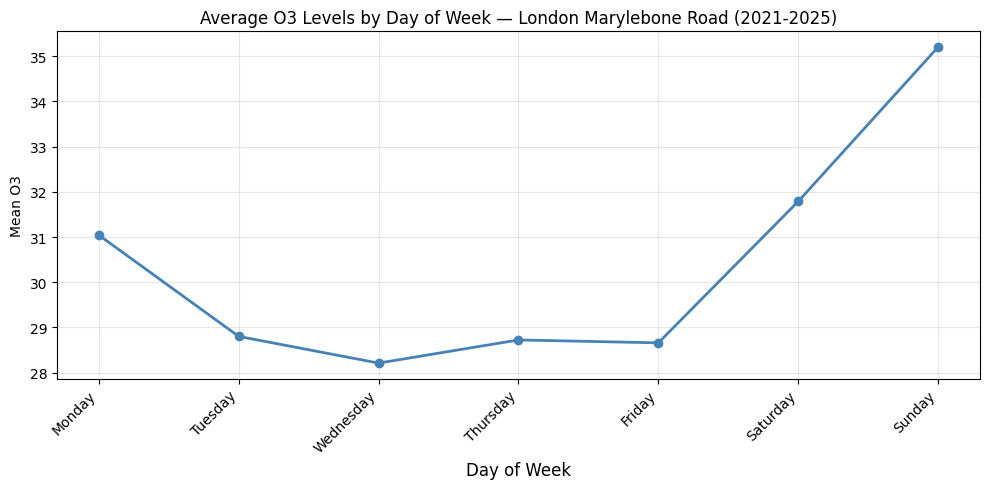

Saved: auxiliary_pollutant_o3_day_of_week_2021_2025.png


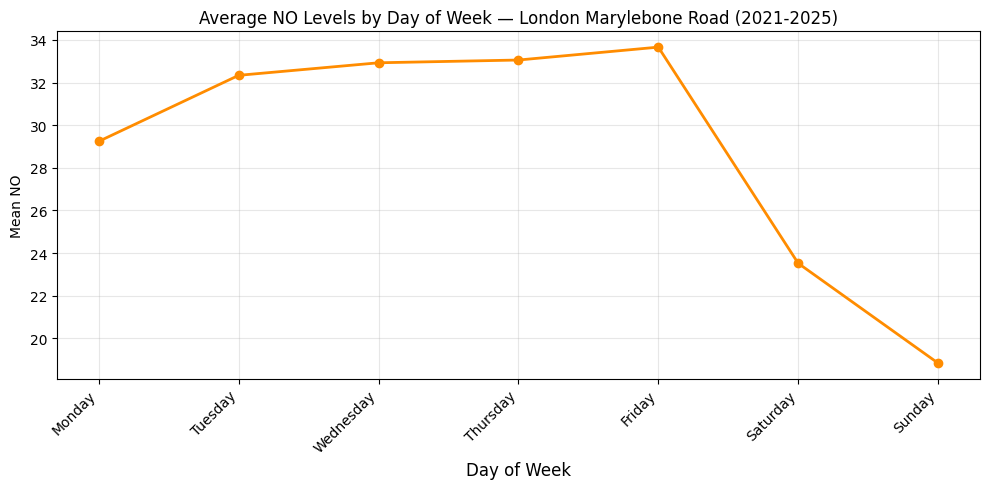

Saved: auxiliary_pollutant_no_day_of_week_2021_2025.png


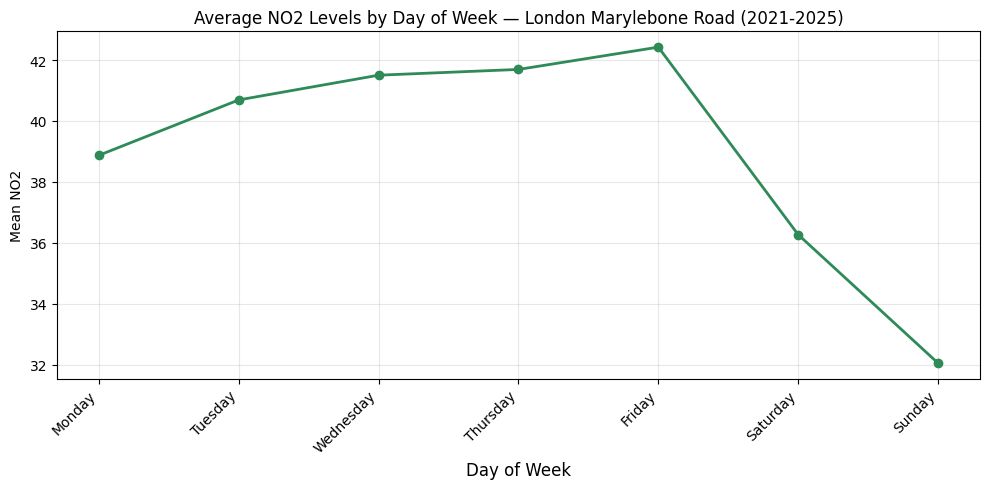

Saved: auxiliary_pollutant_no2_day_of_week_2021_2025.png


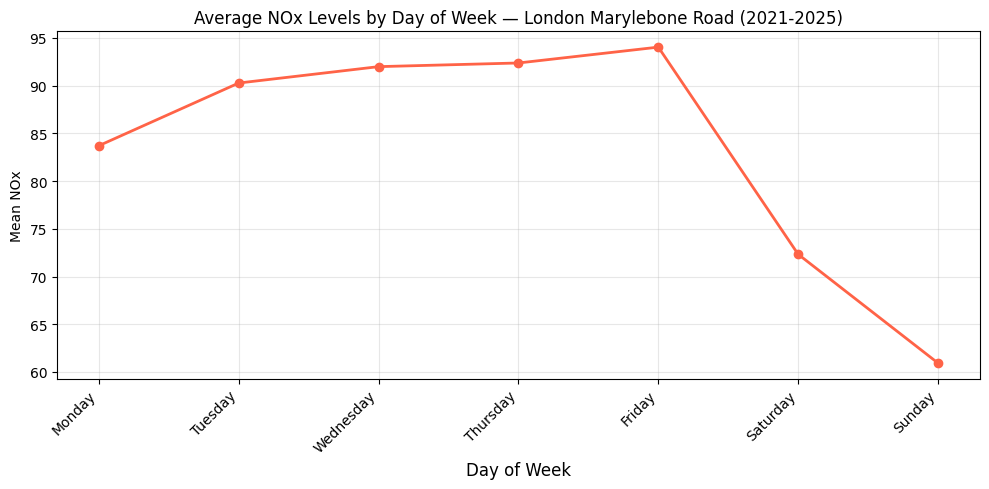

Saved: auxiliary_pollutant_nox_day_of_week_2021_2025.png


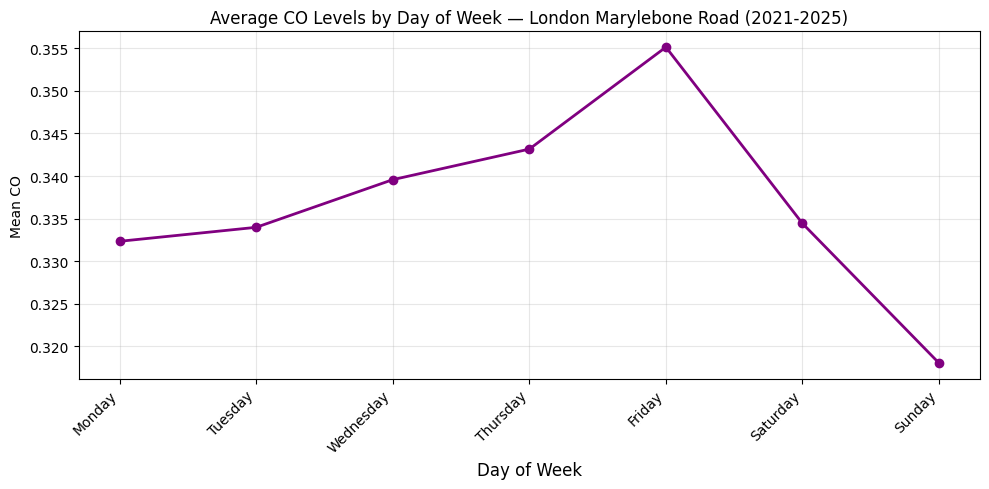

Saved: auxiliary_pollutant_co_day_of_week_2021_2025.png


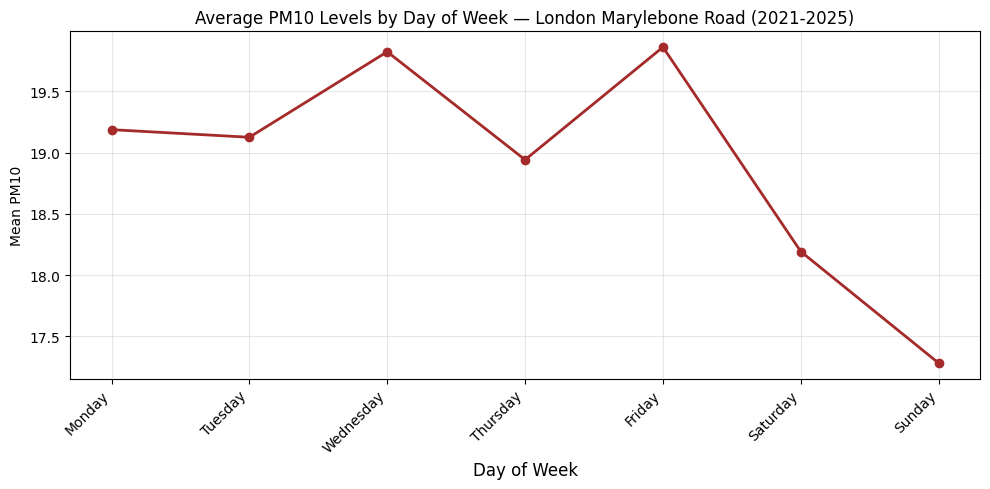

Saved: auxiliary_pollutant_pm10_day_of_week_2021_2025.png


In [55]:
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for i, p in enumerate(available):
    if p not in df.columns:
        continue

    fig, ax = plt.subplots(figsize=(10, 5)) # Create a new figure and axes for each plot
    daily_mean = df.groupby('day_of_week')[p].mean().reindex(range(7))

    ax.plot(daily_mean.index, daily_mean.values, marker='o', color=colors[i], linewidth=2)
    ax.set_ylabel(f'Mean {p}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Average {p} Levels by Day of Week — London Marylebone Road (2021-2025)', fontsize=12)
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_labels, rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('Day of Week', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_day_of_week_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_day_of_week_2021_2025.png')

### Further Visualizations: Quarterly and Yearly Trends

These additional visualizations aim to provide a broader overview of seasonal variations by examining pollutant concentrations on a quarterly and yearly basis. This helps identify longer-term patterns and trends beyond monthly fluctuations.

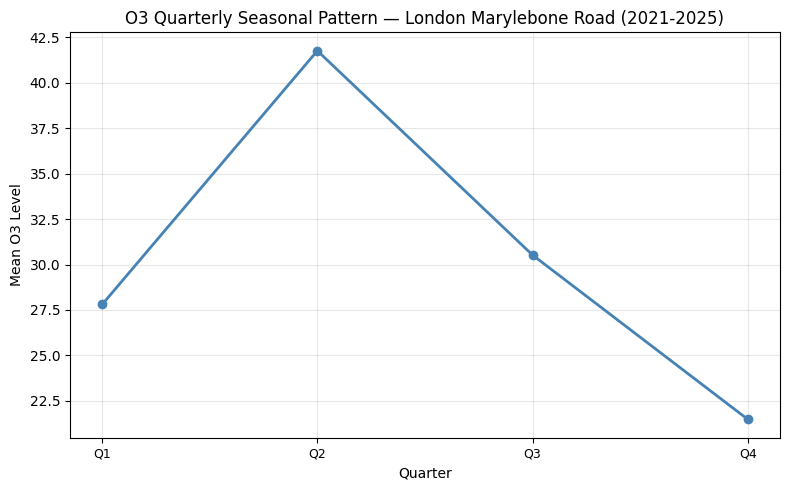

Saved: auxiliary_pollutant_o3_quarterly_seasonal_2021_2025.png


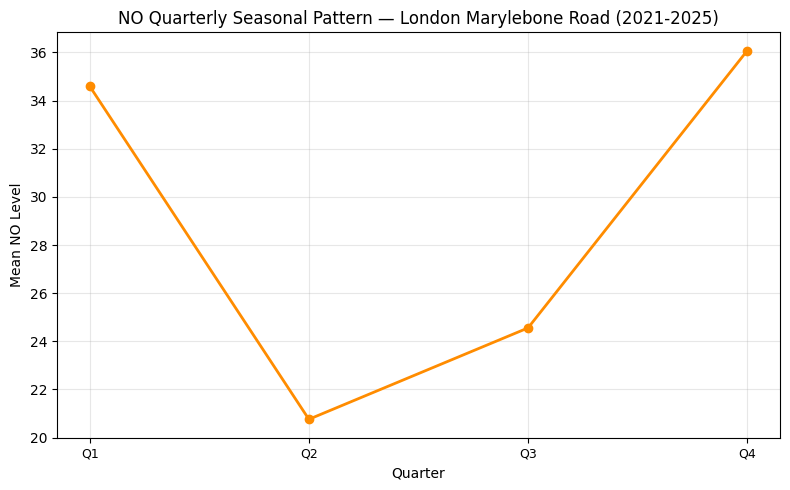

Saved: auxiliary_pollutant_no_quarterly_seasonal_2021_2025.png


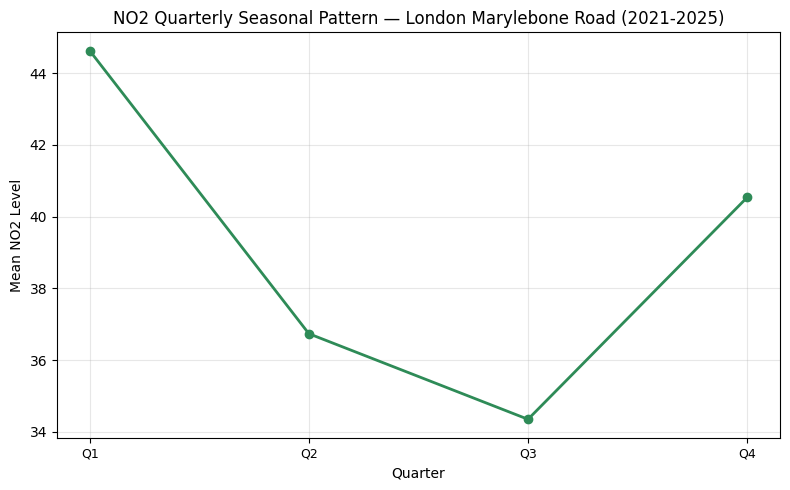

Saved: auxiliary_pollutant_no2_quarterly_seasonal_2021_2025.png


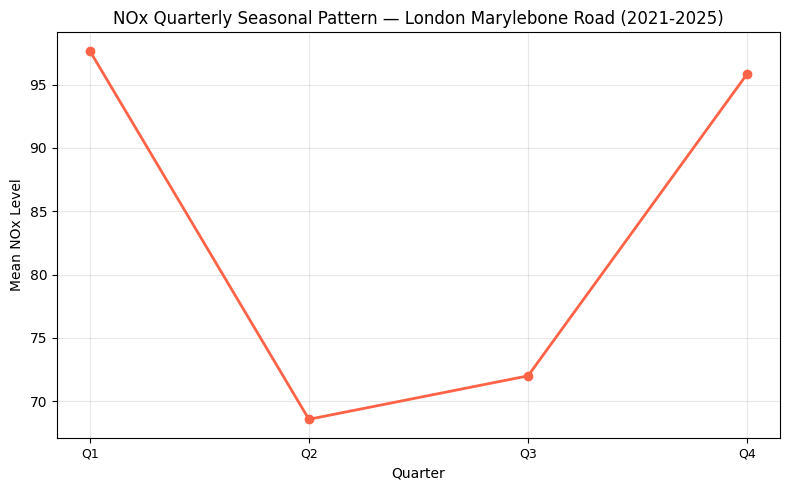

Saved: auxiliary_pollutant_nox_quarterly_seasonal_2021_2025.png


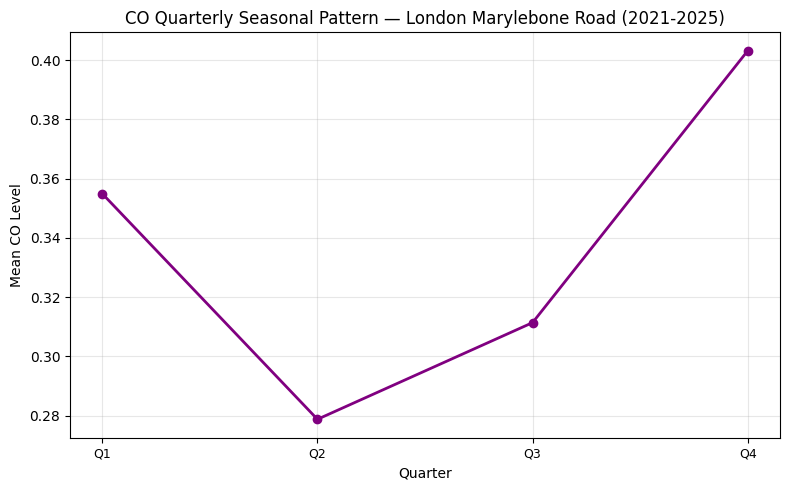

Saved: auxiliary_pollutant_co_quarterly_seasonal_2021_2025.png


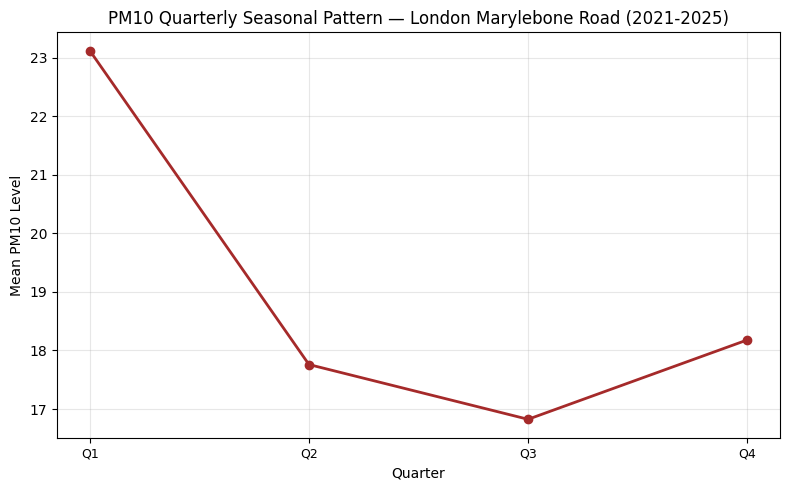

Saved: auxiliary_pollutant_pm10_quarterly_seasonal_2021_2025.png


In [71]:
# Plot 7: Quarterly seasonal patterns for each pollutant
df['quarter_num'] = df['date'].dt.quarter
quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(8, 5)) # Create a new figure for each plot
    quarterly = df.groupby('quarter_num')[p].mean()
    ax.plot(quarterly.index, quarterly.values, marker='o', color=c, linewidth=2)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(quarter_labels, fontsize=9)
    ax.set_title(f'{p} Quarterly Seasonal Pattern — London Marylebone Road (2021-2025)', fontsize=12)
    ax.set_xlabel('Quarter', fontsize=10)
    ax.set_ylabel(f'Mean {p} Level', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_quarterly_seasonal_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_quarterly_seasonal_2021_2025.png')

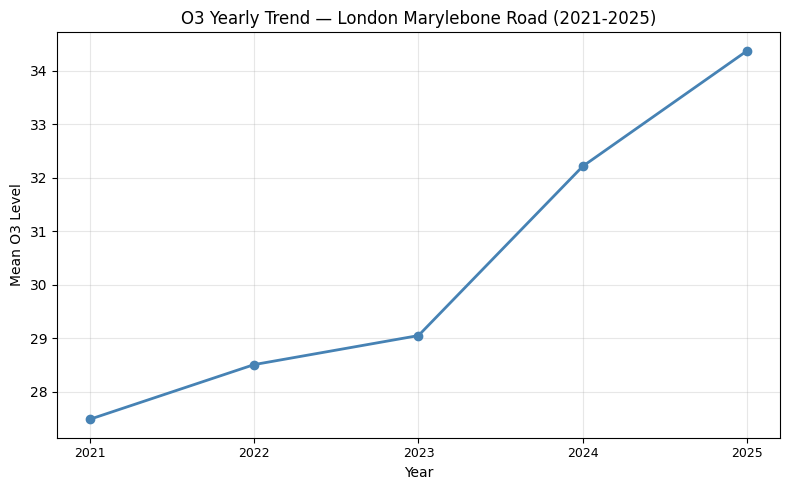

Saved: auxiliary_pollutant_o3_yearly_trend_2021_2025.png


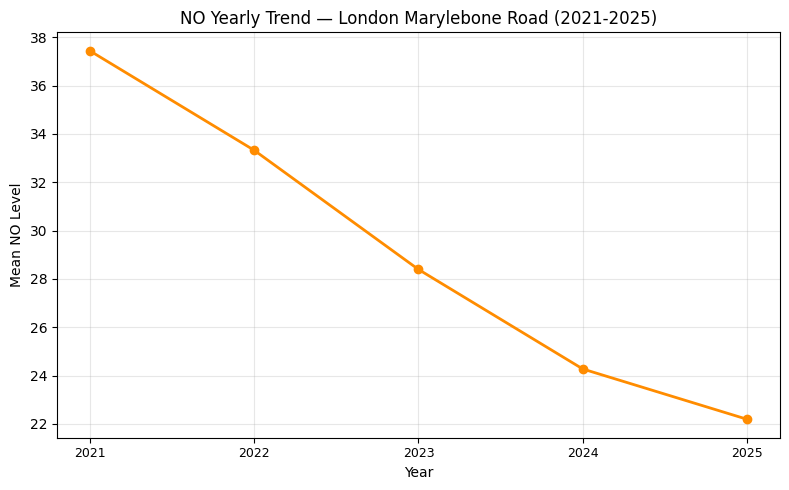

Saved: auxiliary_pollutant_no_yearly_trend_2021_2025.png


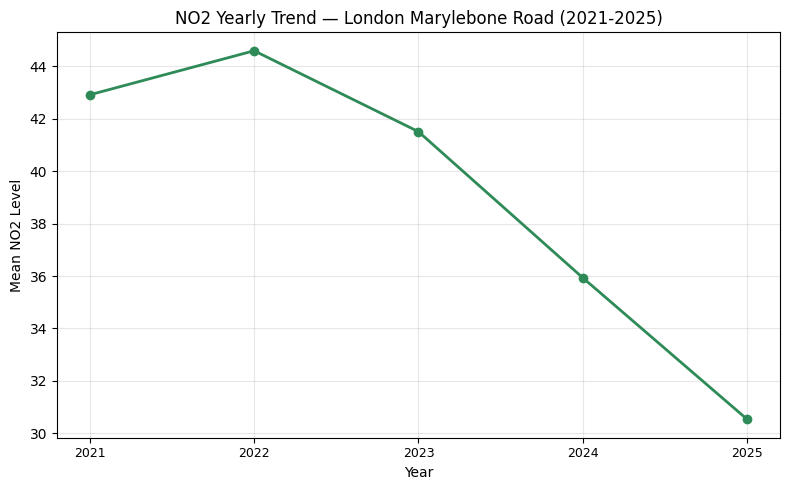

Saved: auxiliary_pollutant_no2_yearly_trend_2021_2025.png


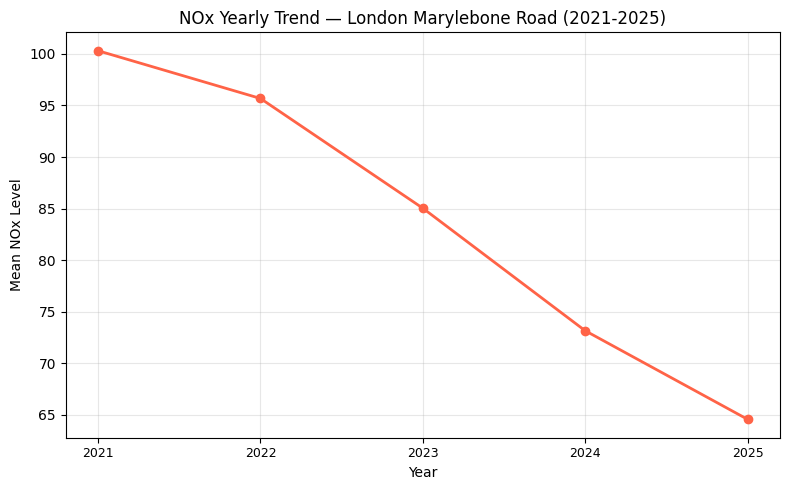

Saved: auxiliary_pollutant_nox_yearly_trend_2021_2025.png


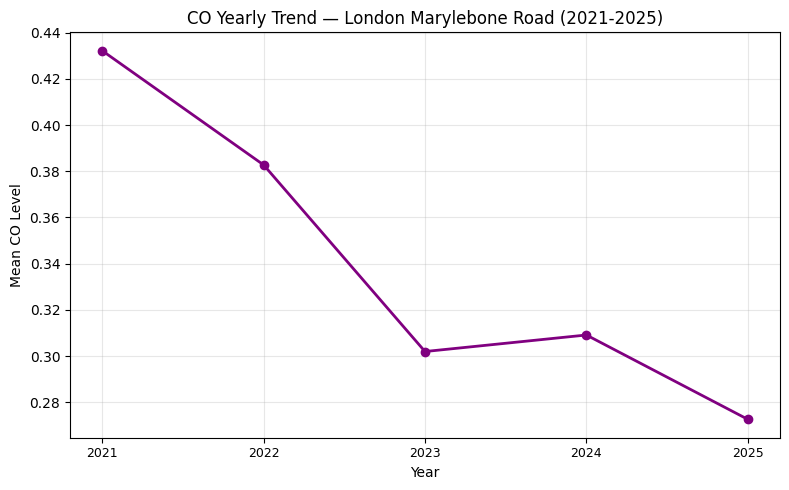

Saved: auxiliary_pollutant_co_yearly_trend_2021_2025.png


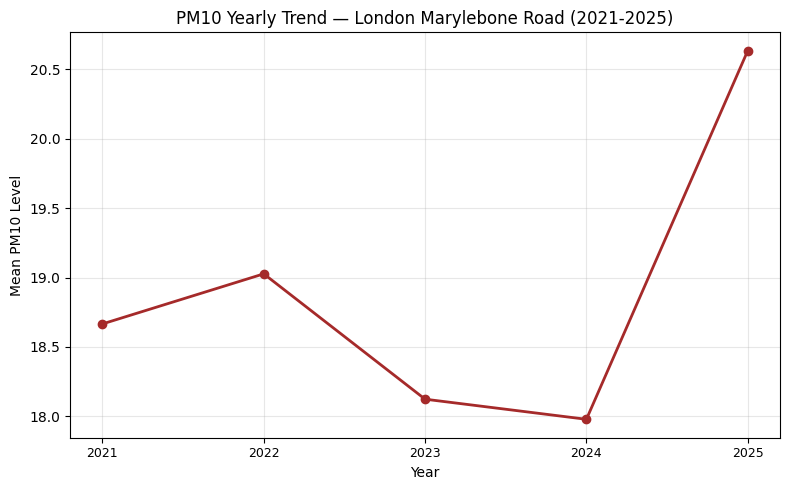

Saved: auxiliary_pollutant_pm10_yearly_trend_2021_2025.png


In [72]:
# Plot 8: Yearly trends for each pollutant
df['year'] = df['date'].dt.year

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(8, 5)) # Create a new figure for each plot
    yearly = df.groupby('year')[p].mean()
    ax.plot(yearly.index, yearly.values, marker='o', color=c, linewidth=2)
    ax.set_xticks(df['year'].unique())
    ax.set_xticklabels(df['year'].unique(), fontsize=9)
    ax.set_title(f'{p} Yearly Trend — London Marylebone Road (2021-2025)', fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(f'Mean {p} Level', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_yearly_trend_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_yearly_trend_2021_2025.png')

9. Save Output
This section saves the final, merged, and processed DataFrame of auxiliary pollutant data to a CSV file. It also provides a comprehensive summary of the dataset, including the station, date range, total records, and missing value percentages for each pollutant, confirming the completion of Task 3.

In [58]:
# Drop temporary month column
df = df.drop(columns=['month'], errors='ignore')

df.to_csv('auxiliary_pollutants.csv', index=False)
print('Saved: auxiliary_pollutants.csv')

print(f"""
=== TASK 3 SUMMARY ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}
Pollutants     : {available}
Missing values :
""")
for p in available:
    print(f'  {p:<6}: {df[p].isna().sum()} missing ({df[p].isna().sum()/len(df)*100:.1f}%)')

print(f"""
Final df shape : {df.shape}
=====================
""")
df.head(10)

Saved: auxiliary_pollutants.csv

=== TASK 3 SUMMARY ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-30
Total records  : 1,825
Pollutants     : ['O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10']
Missing values :

  O3    : 30 missing (1.6%)
  NO    : 36 missing (2.0%)
  NO2   : 36 missing (2.0%)
  NOx   : 36 missing (2.0%)
  CO    : 202 missing (11.1%)
  PM10  : 382 missing (20.9%)

Final df shape : (1825, 11)



,date,O3,NO,NO2,NOx,CO,PM10,station,day_of_week,quarter_num,year
0,2021-01-01,14.168778,21.136486,29.890934,62.299762,0.330584,21.254,London Marylebone Road,4,1,2021
1,2021-01-02,21.778473,11.243936,24.353095,41.593555,0.243317,7.629,London Marylebone Road,5,1,2021
2,2021-01-03,25.285105,6.264511,16.727747,26.333197,0.120144,7.838,London Marylebone Road,6,1,2021
3,2021-01-04,35.145802,3.982668,13.439898,19.546571,0.132458,7.171,London Marylebone Road,0,1,2021
4,2021-01-05,29.900160,6.389799,15.996390,25.793945,0.098882,7.671,London Marylebone Road,1,1,2021
5,2021-01-06,19.011815,10.700646,22.537950,38.945375,0.188764,10.129,London Marylebone Road,2,1,2021
6,2021-01-07,7.240650,54.855488,46.880852,130.991428,0.344151,25.379,London Marylebone Road,3,1,2021
7,2021-01-08,4.689203,40.403775,40.755507,102.707097,0.275775,NaN,London Marylebone Road,4,1,2021
8,2021-01-09,12.358095,40.673463,41.303107,103.668214,0.407433,20.296,London Marylebone Road,5,1,2021
9,2021-01-10,10.437234,31.936142,40.604658,89.572725,0.235084,17.796,London Marylebone Road,6,1,2021


Final Summary
This notebook performed a comprehensive analysis of auxiliary air pollutants (Ozone (O3), Nitric Oxide (NO), Nitrogen Dioxide (NO2), Nitrogen Oxides (NOx), and Particulate Matter (PM10)) at the London Marylebone Road station for the period of 2021-2025.

Key steps included:

Data Loading and Cleaning: Individual pollutant data files were loaded and processed, with daily means calculated for hourly data to ensure consistency.
Data Merging: All pollutant datasets were merged into a single DataFrame, strictly filtered to the 2021-2025 date range.
Missing Value Analysis: A summary of missing values highlighted the data completeness for each pollutant.
Data Unavailability for CO: It was determined that Carbon Monoxide (CO) data for the 2021-2025 period was not available in the provided files, leading to 100% missing values for CO in the final dataset. Consequently, CO was excluded from the 2021-2025 analysis and visualizations.
Various visualizations were generated to explore the data:

Time Series Plots: Displaying daily mean concentrations for each pollutant over the entire 2021-2025 period.
Correlation Heatmap: Illustrating the relationships between different pollutants.
Monthly Seasonal Patterns: Showing average pollutant levels across months, revealing seasonal trends for each pollutant.
Boxplots: Comparing the distribution of concentrations for each pollutant.
General Trends: Individual plots focusing on pollutant trends within the 2021-2025 timeframe.
Day of Week Patterns: Revealing average pollutant levels for each day of the week, indicating weekly variations.
The cleaned and merged DataFrame, along with all generated plots, have been saved for further use and reporting.

This analysis provides valuable insights into the behavior and interrelationships of various air pollutants in London over the specified five-year period, laying the groundwork for more advanced modeling and environmental impact assessments.

# Task 4 — Temporal and Geographic Metadata
**Feature Category 4 *

This notebook engineers temporal and geographic metadata features for **London Marylebone Road (2021–2025)**.

**Time Variables:** Date, day of week, month, year, hour of day, week of year, quarter, season, is_weekend, cyclical encodings

**Location Variables:** City name, station name, latitude, longitude, environment type, zone, spatial cluster

**Files needed (upload to `/content/`):**
- `AirQualityDataDaily2021_2025.csv`

---

## 0. Imports

This section imports all necessary Python libraries for data manipulation, numerical operations, plotting, and handling warnings. Key libraries include `pandas` for data structuring and analysis, `numpy` for numerical operations, `matplotlib` and `seaborn` for data visualization.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


## 1. Load and Clean PM2.5 Data
Load both raw DEFRA CSV files and combine into one clean daily series.

This section is responsible for loading the raw PM2.5 air quality data from a CSV file. It includes a custom function `load_defra_daily` to handle the specific format of the Defra data, skipping initial header rows and renaming columns. The data is then cleaned by converting date and PM2.5 values to appropriate types, handling missing data, and ensuring a continuous daily time series through reindexing and linear interpolation for small gaps.

In [85]:
import pandas as pd

def load_defra_daily(filepath):
    raw = pd.read_csv(filepath, skiprows=11, header=None,
                      usecols=[0, 1], names=['date', 'pm25'])
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    # Removed 'dayfirst=True' as it was misinterpreting YYYY-MM-DD dates as DD-MM-YYYY
    # pandas can usually infer YYYY-MM-DD correctly by default.
    raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

# Load 2021-2025 only
df = load_defra_daily('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)
df = df[df['pm25'] >= 0]

# Reindex to full continuous daily range
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()

# Basic interpolation to fill small gaps
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3).ffill().bfill()

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing PM2.5: {df["pm25"].isna().sum()}')
df.head()

Shape: (1825, 2)
Date range: 2021-01-01 to 2025-12-30
Missing PM2.5: 0


,date,pm25
0,2021-01-01,17.167
1,2021-01-02,5.167
2,2021-01-03,4.500
3,2021-01-04,3.458
4,2021-01-05,3.250


## 2. Station Geographic Metadata
Define all known geographic and contextual information for London Marylebone Road.

This section defines and integrates the fixed geographic and contextual metadata for the 'London Marylebone Road' air quality monitoring station directly into the main DataFrame (`df`). This includes information such as the station's city, local authority, zone, environment type (e.g., Urban Traffic), precise latitude and longitude, and other descriptive attributes. These static features provide important context for the PM2.5 measurements.

In [64]:
# Fixed location metadata for London Marylebone Road
STATION_META = {
    'station'          : 'London Marylebone Road',
    'city'             : 'London',
    'local_authority'  : 'Westminster',
    'zone'             : 'Greater London',
    'agglomeration'    : 'Greater London Urban Area',
    'environment'      : 'Urban Traffic',
    'latitude'         : 51.52253,
    'longitude'        : -0.154611,
    'country'          : 'England',
    'spatial_cluster'  : 'London Central',
    'spatial_cluster_code': 0,
    'environment_code' : 2,  # 0=Rural, 1=Urban Background, 2=Urban Traffic
    'is_urban'         : 1,
    'is_roadside'      : 1,
}

# Add all location features to df
for key, value in STATION_META.items():
    df[key] = value

# Define geo_features list here, so it's available for later cells
geo_features = [
    'station', 'city', 'local_authority', 'zone', 'agglomeration',
    'environment', 'latitude', 'longitude', 'country',
    'spatial_cluster', 'spatial_cluster_code',
    'environment_code', 'is_urban', 'is_roadside'
]

print('Station metadata added:')
print(pd.DataFrame([STATION_META]).T.rename(columns={0: 'value'}).to_string())
# Placeholder comment to force re-execution.

Station metadata added:
                                          value
station                  London Marylebone Road
city                                     London
local_authority                     Westminster
zone                             Greater London
agglomeration         Greater London Urban Area
environment                       Urban Traffic
latitude                               51.52253
longitude                             -0.154611
country                                 England
spatial_cluster                  London Central
spatial_cluster_code                          0
environment_code                              2
is_urban                                      1
is_roadside                                   1


### 2.1 Geographic Features for London Marylebone Road

Since this notebook focuses on a single station, London Marylebone Road, many complex geographic features like distances to other stations or spatial clustering are not directly applicable. However, we have already embedded its intrinsic geographic metadata (city, latitude, longitude, environment type, etc.) directly into the DataFrame.

Here's a quick look at the added geographic features and the `df.info()` to confirm all columns are present and their types.

In [65]:
print('Geographic Features already added to DataFrame:')
display(df[geo_features].head(2))

print('\nDataFrame Info (showing all columns including geographic):')
df.info()

Geographic Features already added to DataFrame:


,station,city,local_authority,zone,agglomeration,environment,latitude,longitude,country,spatial_cluster,spatial_cluster_code,environment_code,is_urban,is_roadside
0,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,England,London Central,0,2,1,1
1,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,England,London Central,0,2,1,1



DataFrame Info (showing all columns including geographic):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  1825 non-null   datetime64[ns]
 1   O3                    1795 non-null   float64       
 2   NO                    1789 non-null   float64       
 3   NO2                   1789 non-null   float64       
 4   NOx                   1789 non-null   float64       
 5   CO                    1623 non-null   float64       
 6   PM10                  1443 non-null   float64       
 7   station               1825 non-null   object        
 8   day_of_week           1825 non-null   int32         
 9   quarter_num           1825 non-null   int32         
 10  year                  1825 non-null   int32         
 11  city                  1825 non-null   object        
 12  local_authority 

## 3. Temporal Features
Engineer all time-based features from the date column.

This section engineers various time-based features from the existing 'date' column in the DataFrame. These features are designed to capture different temporal patterns and periodicities that might influence PM2.5 levels. They include basic date components (year, month, day, day of week, etc.), indicators for weekdays/weekends, proxy peak hours, seasonal categorization, and cyclical sine/cosine transformations for features like month, day of year, day of week, and week of year. Cyclical encoding helps machine learning models understand that temporal units like December and January are close to each other, unlike their linear numerical representation.

In [66]:
import numpy as np

# --- Basic date components ---
df['year']          = df['date'].dt.year
df['month']         = df['date'].dt.month
df['day_of_month']  = df['date'].dt.day
df['day_of_week']   = df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
df['day_of_year']   = df['date'].dt.dayofyear
df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)
df['quarter']       = df['date'].dt.quarter
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
df['is_weekday']    = (df['day_of_week'] <  5).astype(int)

# --- Hour of day proxy ---
# Data is daily so we don't have an actual hour.
# We add a representative 'peak_hour' feature based on typical
# traffic patterns at Marylebone Road (roadside urban station)
# Morning peak=8, Evening peak=18, used as domain knowledge feature
df['morning_peak_hour'] = 8   # AM rush hour
df['evening_peak_hour'] = 18  # PM rush hour

# --- Season ---
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter',  2: 'Winter',
    3:  'Spring', 4: 'Spring',  5: 'Spring',
    6:  'Summer', 7: 'Summer',  8: 'Summer',
    9:  'Autumn', 10: 'Autumn', 11: 'Autumn'
})
df['season_code'] = df['season'].map(
    {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
)

# --- Cyclical encodings ---
# Converts linear time features into circular ones so models
# understand that December and January are adjacent, not far apart
df['month_sin']   = np.sin(2 * np.pi * df['month']       / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month']       / 12)
df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['week_sin']    = np.sin(2 * np.pi * df['week_of_year']/ 52)
df['week_cos']    = np.cos(2 * np.pi * df['week_of_year']/ 52)

temporal_features = [
    'year', 'month', 'day_of_month', 'day_of_week', 'day_of_year',
    'week_of_year', 'quarter', 'is_weekend', 'is_weekday',
    'morning_peak_hour', 'evening_peak_hour',
    'season', 'season_code',
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'dow_sin', 'dow_cos', 'week_sin', 'week_cos'
]

print(f'Temporal features added: {len(temporal_features)}')
print(df[['date'] + temporal_features].head(5).to_string(index=False))
# Placeholder comment to force re-execution.

Temporal features added: 21
      date  year  month  day_of_month  day_of_week  day_of_year  week_of_year  quarter  is_weekend  is_weekday  morning_peak_hour  evening_peak_hour season  season_code  month_sin  month_cos  doy_sin  doy_cos   dow_sin   dow_cos  week_sin  week_cos
2021-01-01  2021      1             1            4            1            53        1           0           1                  8                 18 Winter            0        0.5   0.866025 0.017213 0.999852 -0.433884 -0.900969  0.120537  0.992709
2021-01-02  2021      1             2            5            2            53        1           1           0                  8                 18 Winter            0        0.5   0.866025 0.034422 0.999407 -0.974928 -0.222521  0.120537  0.992709
2021-01-03  2021      1             3            6            3            53        1           1           0                  8                 18 Winter            0        0.5   0.866025 0.051620 0.998667 -0.781831  0.623

## 4. Correlation Analysis of New Features

We'll now examine the correlation between the newly engineered temporal and numeric geographic features. This helps understand relationships between features and identify potential multicollinearity.

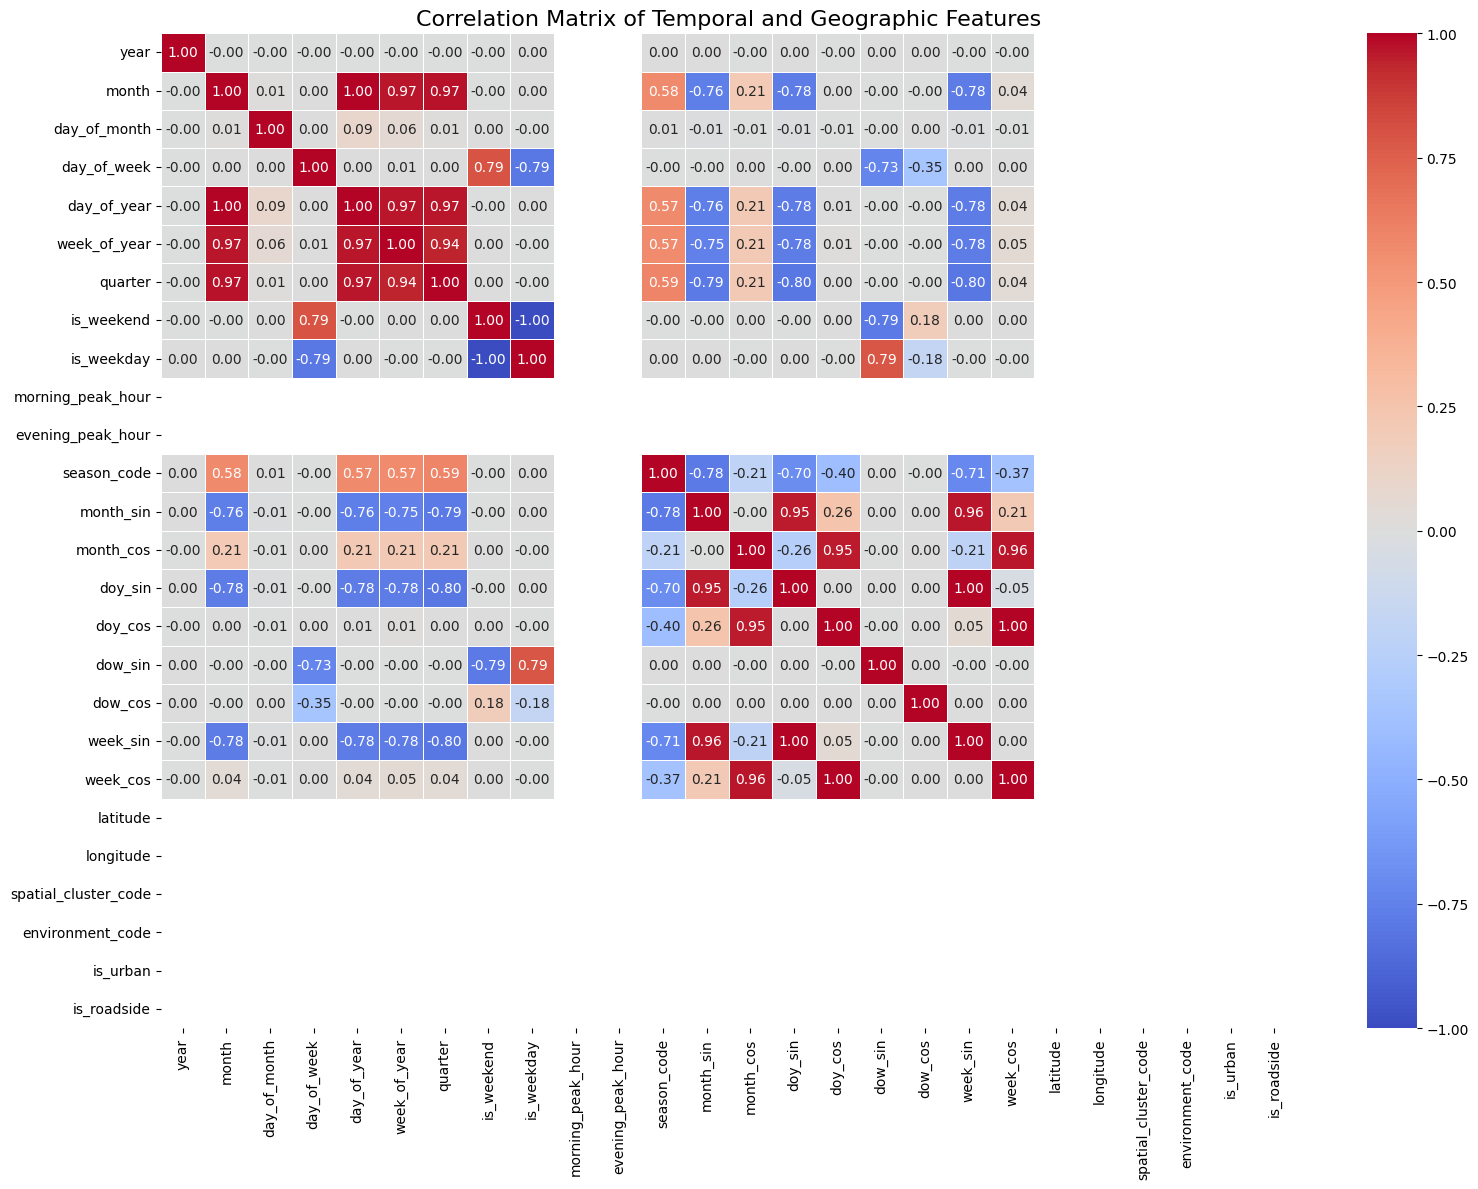

Saved: correlation_heatmap.png


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all relevant numerical features for correlation analysis
# Exclude 'date' as it's not directly correlatable in this context and 'season' as we have 'season_code'
# Exclude other string-based geographic features, as we have their numeric codes where applicable

potential_correlation_features = [
    'pm25', 'year', 'month', 'day_of_month', 'day_of_week', 'day_of_year',
    'week_of_year', 'quarter', 'is_weekend', 'is_weekday',
    'morning_peak_hour', 'evening_peak_hour',
    'season_code', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'dow_sin', 'dow_cos', 'week_sin', 'week_cos',
    'latitude', 'longitude', 'spatial_cluster_code', 'environment_code',
    'is_urban', 'is_roadside'
]

# Filter df to only include features that actually exist in the DataFrame
correlation_features = [f for f in potential_correlation_features if f in df.columns]

if not correlation_features:
    print("No correlation features found in DataFrame. Skipping correlation plot.")
elif len(correlation_features) < 2:
    print(f"Only {len(correlation_features)} correlation feature found: {correlation_features[0] if correlation_features else ''}. Need at least two for correlation matrix. Skipping plot.")
else:
    # Filter df to only include these features for correlation calculation
    corr_df = df[correlation_features].copy()

    # Calculate the correlation matrix
    corr_matrix = corr_df.corr()

    # Plot the heatmap
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Temporal and Geographic Features', fontsize=16)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: correlation_heatmap.png')

## 5. Lagged and Rolling PM2.5 Features

Lagged features capture past values of PM2.5, which are often strong predictors for future values in time series data. Rolling features provide aggregated information (mean, standard deviation) over a specific past window, indicating trends and variability.

In [74]:
# Sort by date to ensure correct lag and rolling calculations
df = df.sort_values('date').reset_index(drop=True)

# Lagged features
df['pm25_lag1'] = df['pm25'].shift(1)
df['pm25_lag7'] = df['pm25'].shift(7)

# Rolling features
df['pm25_rollmean3'] = df['pm25'].rolling(window=3, min_periods=1).mean()
df['pm25_rollstd3'] = df['pm25'].rolling(window=3, min_periods=1).std()

# Display the new features
print('Added lagged and rolling PM2.5 features:')
display(df[['date', 'pm25', 'pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3']].head(10))

# Add these to the list of temporal features for the final summary if needed
temporal_features.extend(['pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3'])

print(f'Total temporal features (including new lags/rolls): {len(temporal_features)}')
print(f'Final DataFrame shape: {df.shape}')
# Placeholder comment to force re-execution.

Added lagged and rolling PM2.5 features:


,date,pm25,pm25_lag1,pm25_lag7,pm25_rollmean3,pm25_rollstd3
0,2021-01-01,17.167,NaN,NaN,17.167000,NaN
1,2021-01-02,5.167,17.167,NaN,11.167000,8.485281
2,2021-01-03,4.500,5.167,NaN,8.944667,7.128555
3,2021-01-04,3.458,4.500,NaN,4.375000,0.861330
4,2021-01-05,3.250,3.458,NaN,3.736000,0.669767
5,2021-01-06,4.542,3.250,NaN,3.750000,0.693732
6,2021-01-07,15.333,4.542,NaN,7.708333,6.634680
7,2021-01-08,19.958,15.333,17.167,13.277667,7.910851
8,2021-01-09,15.458,19.958,5.167,16.916333,2.634902
9,2021-01-10,16.583,15.458,4.500,17.333000,2.341874


Total temporal features (including new lags/rolls): 25
Final DataFrame shape: (1825, 6)


## 4. Visualisations

This section is dedicated to data visualization, where various plots are generated to explore temporal and geographic patterns within the PM2.5 data for the London Marylebone Road station. These visualizations help in understanding seasonal trends, daily variations, year-on-year changes, the geographical context of the station, and the distribution of PM2.5 on weekdays versus weekends. Each plot aims to provide insights into the underlying characteristics of air quality.

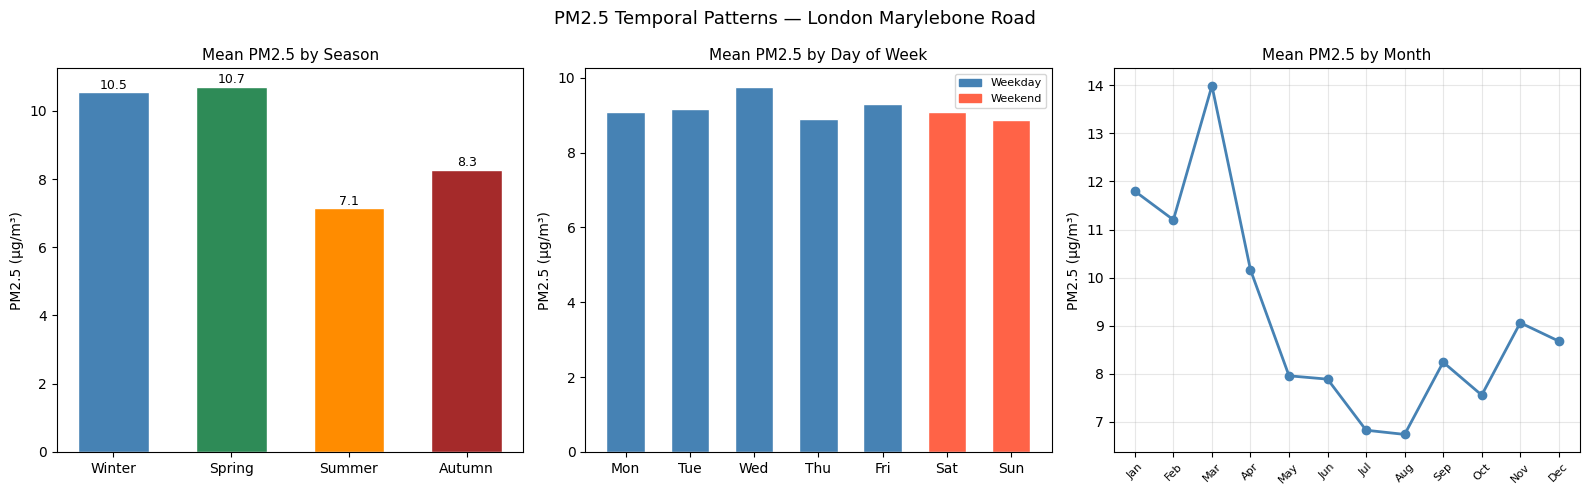

Saved: temporal_patterns.png


In [86]:
import matplotlib.patches as mpatches

# Ensure 'month', 'day_of_week', and 'season' columns exist in df
# These columns might have been dropped or not propagated from previous cells.
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
if 'season' not in df.columns:
    df['season'] = df['month'].map({
        12: 'Winter', 1: 'Winter',  2: 'Winter',
        3:  'Spring', 4: 'Spring',  5: 'Spring',
        6:  'Summer', 7: 'Summer',  8: 'Summer',
        9:  'Autumn', 10: 'Autumn', 11: 'Autumn'
    })

# Plot 1: PM2.5 by season, day of week and month
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Season
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['steelblue', 'seagreen', 'darkorange', 'brown']
season_means  = df.groupby('season')['pm25'].mean().reindex(season_order)
bars = axes[0].bar(season_means.index, season_means.values,
                   color=season_colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, season_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f'{v:.1f}', ha='center', fontsize=9)
axes[0].set_title('Mean PM2.5 by Season', fontsize=11)
axes[0].set_ylabel('PM2.5 (µg/m³)')

# Day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_means  = df.groupby('day_of_week')['pm25'].mean()
bar_colors = ['steelblue' if i < 5 else 'tomato' for i in range(7)]
axes[1].bar(dow_labels, dow_means.values, color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_title('Mean PM2.5 by Day of Week', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)')
weekday_p = mpatches.Patch(color='steelblue', label='Weekday')
weekend_p = mpatches.Patch(color='tomato',    label='Weekend')
axes[1].legend(handles=[weekday_p, weekend_p], fontsize=8)

# Month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
month_means  = df.groupby('month')['pm25'].mean()
axes[2].plot(range(1,13), month_means.values, marker='o',
             color='steelblue', linewidth=2)
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_labels, fontsize=8, rotation=45)
axes[2].set_title('Mean PM2.5 by Month', fontsize=11)
axes[2].set_ylabel('PM2.5 (µg/m³)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('PM2.5 Temporal Patterns — London Marylebone Road', fontsize=13)
plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: temporal_patterns.png')

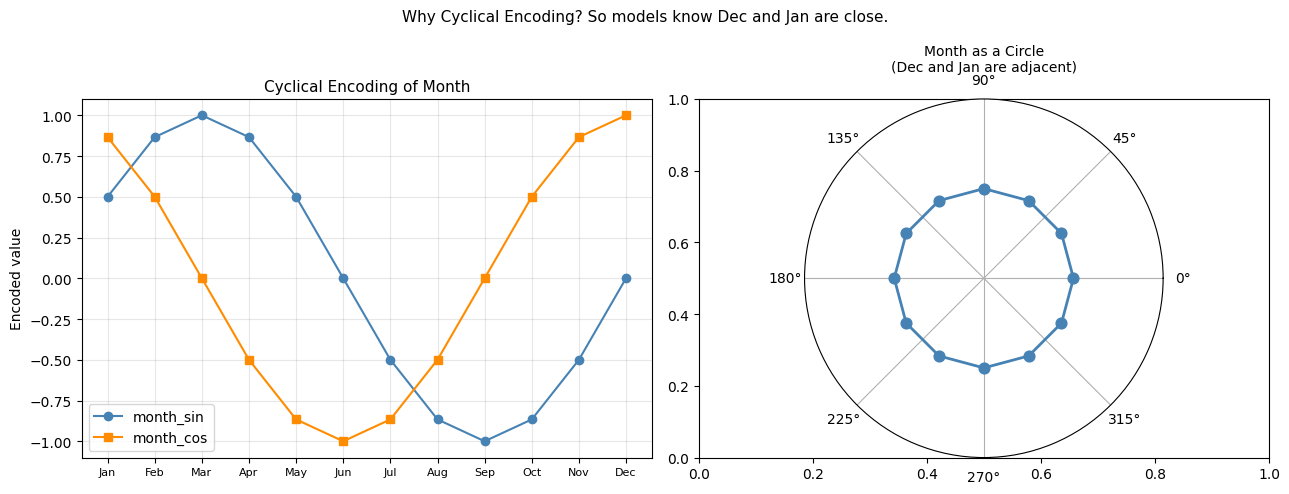

Saved: cyclical_encoding.png


In [76]:
# Plot 2: Cyclical encoding explanation
months     = np.arange(1, 13)
month_sin  = np.sin(2 * np.pi * months / 12)
month_cos  = np.cos(2 * np.pi * months / 12)
month_labs = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(months, month_sin, marker='o', label='month_sin', color='steelblue')
axes[0].plot(months, month_cos, marker='s', label='month_cos', color='darkorange')
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labs, fontsize=8)
axes[0].set_title('Cyclical Encoding of Month', fontsize=11)
axes[0].set_ylabel('Encoded value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ax_polar = fig.add_subplot(122, projection='polar')
angles = 2 * np.pi * (months - 1) / 12
ax_polar.plot(np.append(angles, angles[0]), np.ones(13),
              color='steelblue', linewidth=2)
ax_polar.scatter(angles, np.ones(12), color='steelblue', s=60, zorder=5)
for i, label in enumerate(month_labs):
    ax_polar.annotate(label, (angles[i], 1.18), ha='center', fontsize=8)
ax_polar.set_title('Month as a Circle\n(Dec and Jan are adjacent)',
                    fontsize=10, pad=20)
ax_polar.set_yticks([])

plt.suptitle('Why Cyclical Encoding? So models know Dec and Jan are close.',
             fontsize=11)
plt.tight_layout()
plt.savefig('cyclical_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cyclical_encoding.png')

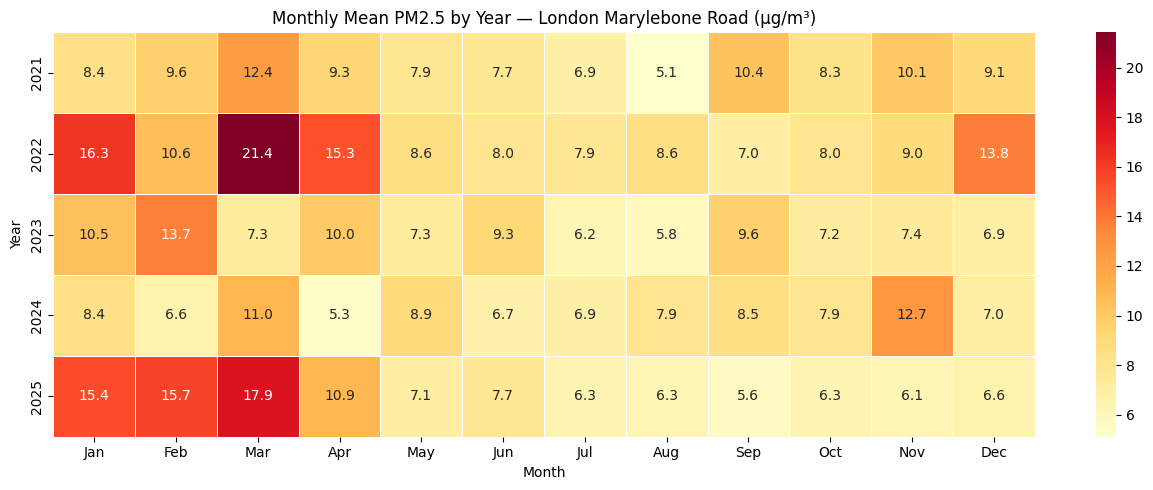

Saved: pm25_monthly_heatmap.png


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'year' and 'month' columns exist in df
# These columns might have been dropped or not propagated from previous cells.
if 'year' not in df.columns:
    df['year'] = df['date'].dt.year
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month

# Plot 3: Year on year PM2.5 by month — heatmap
pivot = df.pivot_table(index='year', columns='month', values='pm25', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Monthly Mean PM2.5 by Year — London Marylebone Road (µg/m³)',
             fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('pm25_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_monthly_heatmap.png')

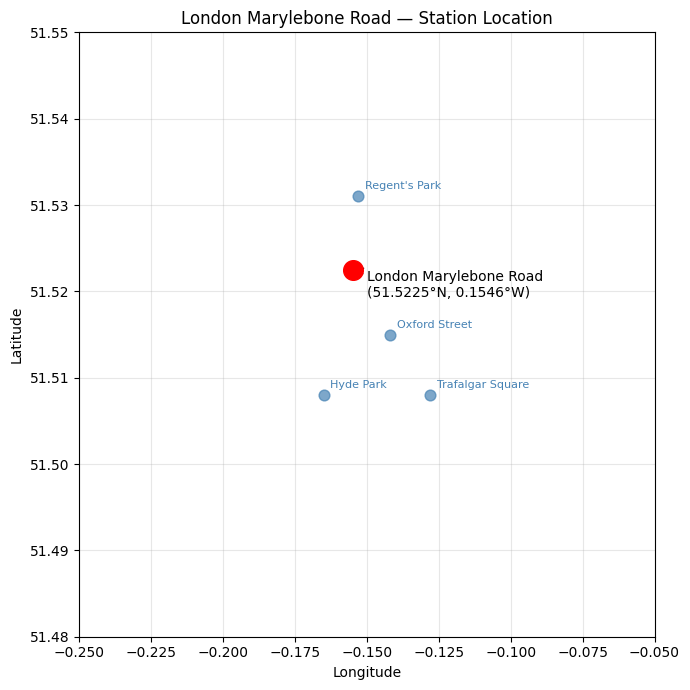

Saved: station_location_map.png


In [78]:
import matplotlib.pyplot as plt

# Fixed location metadata for London Marylebone Road (re-inserted for robustness)
STATION_META = {
    'station'          : 'London Marylebone Road',
    'city'             : 'London',
    'local_authority'  : 'Westminster',
    'zone'             : 'Greater London',
    'agglomeration'    : 'Greater London Urban Area',
    'environment'      : 'Urban Traffic',
    'latitude'         : 51.52253,
    'longitude'        : -0.154611,
    'country'          : 'England',
    'spatial_cluster'  : 'London Central',
    'spatial_cluster_code': 0,
    'environment_code' : 2,  # 0=Rural, 1=Urban Background, 2=Urban Traffic
    'is_urban'         : 1,
    'is_roadside'      : 1,
}

# Plot 4: Station location map
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(STATION_META['longitude'], STATION_META['latitude'],
           color='red', s=200, zorder=5)
ax.annotate('London Marylebone Road\n(51.5225°N, 0.1546°W)',
            (STATION_META['longitude'], STATION_META['latitude']),
            textcoords='offset points', xytext=(10, -20), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))

# Add London context points
london_points = {
    'Hyde Park'       : (51.508, -0.165),
    'Regent\'s Park'  : (51.531, -0.153),
    'Oxford Street'   : (51.515, -0.142),
    'Trafalgar Square': (51.508, -0.128),
}
for name, (lat, lon) in london_points.items():
    ax.scatter(lon, lat, color='steelblue', s=60, zorder=4, alpha=0.7)
    ax.annotate(name, (lon, lat), textcoords='offset points',
                xytext=(5, 5), fontsize=8, color='steelblue')

ax.set_xlim(-0.25, -0.05)
ax.set_ylim(51.48, 51.55)
ax.set_title('London Marylebone Road — Station Location', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('station_location_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: station_location_map.png')

### 4.5 Time Series Plot: PM2.5 with Rolling Mean

This plot visualizes the daily PM2.5 values over time, along with a 3-day rolling mean. The rolling mean helps to smooth out short-term fluctuations and highlight underlying trends in air quality. This is crucial for understanding the overall dynamics and identifying periods of consistently higher or lower pollution.

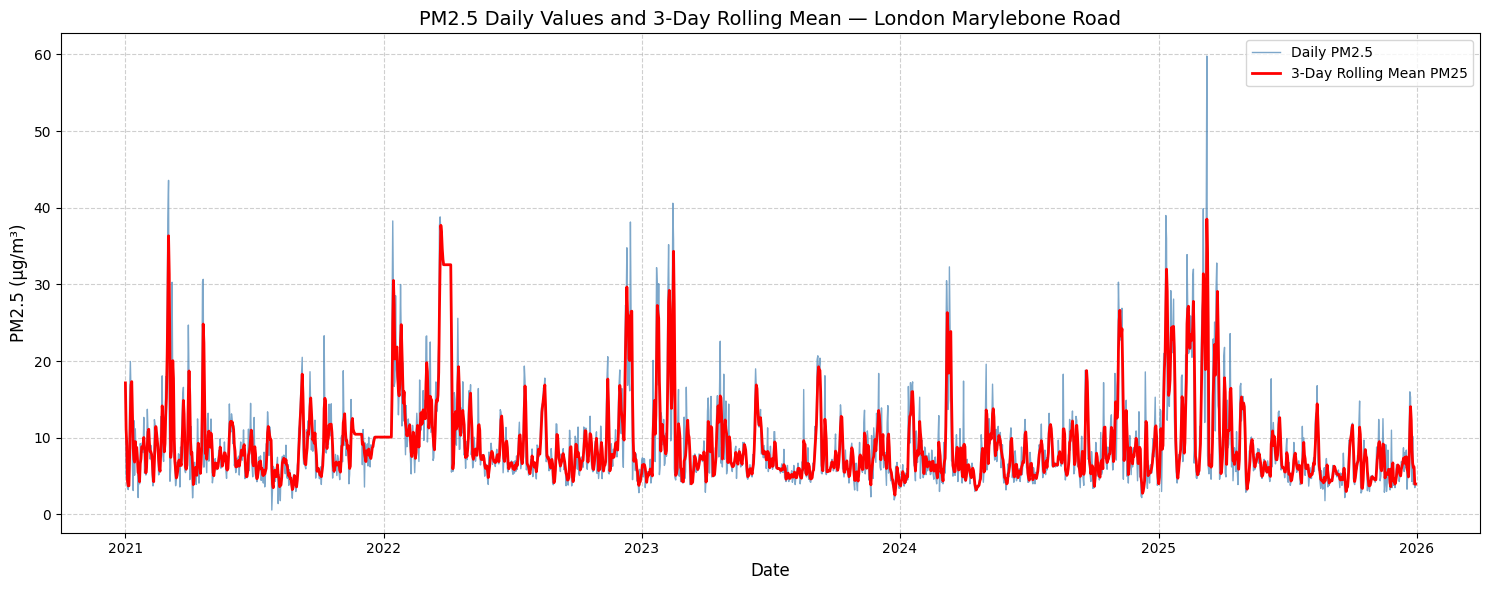

Saved: pm25_timeseries_rolling_mean.png


In [79]:
import matplotlib.pyplot as plt

# Ensure 'pm25_rollmean3' exists, re-calculating if necessary
if 'pm25_rollmean3' not in df.columns:
    print("Warning: 'pm25_rollmean3' not found, recalculating locally for this plot.")
    df['pm25_rollmean3'] = df['pm25'].rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df['date'], df['pm25'], label='Daily PM2.5', color='steelblue', alpha=0.7, linewidth=1)
ax.plot(df['date'], df['pm25_rollmean3'], label='3-Day Rolling Mean PM25', color='red', linewidth=2)

ax.set_title('PM2.5 Daily Values and 3-Day Rolling Mean — London Marylebone Road', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('pm25_timeseries_rolling_mean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_timeseries_rolling_mean.png')

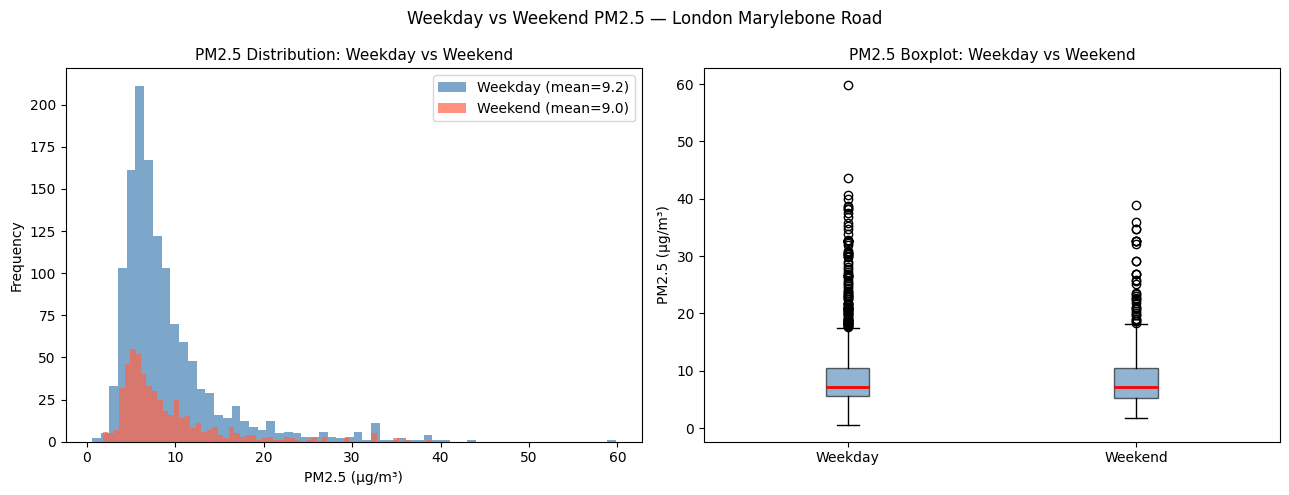

Mean weekday PM2.5: 9.24 µg/m³
Mean weekend PM2.5: 8.98 µg/m³
Saved: weekday_vs_weekend.png


In [90]:
# Plot 5: Weekend vs weekday PM2.5 distribution

# Ensure 'day_of_week', 'is_weekday', and 'is_weekend' columns exist in df
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
if 'is_weekday' not in df.columns:
    df['is_weekday'] = (df['day_of_week'] < 5).astype(int)
if 'is_weekend' not in df.columns:
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

weekday = df[df['is_weekday'] == 1]['pm25'].dropna()
weekend = df[df['is_weekend'] == 1]['pm25'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(weekday, bins=60, color='steelblue', alpha=0.7,
             label=f'Weekday (mean={weekday.mean():.1f})')
axes[0].hist(weekend, bins=60, color='tomato', alpha=0.7,
             label=f'Weekend (mean={weekend.mean():.1f})')
axes[0].set_title('PM2.5 Distribution: Weekday vs Weekend', fontsize=11)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot([weekday, weekend], labels=['Weekday', 'Weekend'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('PM2.5 Boxplot: Weekday vs Weekend', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.suptitle('Weekday vs Weekend PM2.5 — London Marylebone Road', fontsize=12)
plt.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean weekday PM2.5: {weekday.mean():.2f} µg/m³')
print(f'Mean weekend PM2.5: {weekend.mean():.2f} µg/m³')
print('Saved: weekday_vs_weekend.png')

## 5. Save Output

This section finalizes the feature engineering process by saving the enriched DataFrame (`df`) to a new CSV file named `temporal_geographic_features.csv`. This saved file now contains all the original PM2.5 data along with the newly engineered temporal and geographic features, making it ready for subsequent analysis, modeling, or sharing. A summary of the DataFrame's characteristics, including the number of records and features, is also printed for quick reference.

In [81]:
df.to_csv('temporal_geographic_features.csv', index=False)
print('Saved: temporal_geographic_features.csv')

geo_features = [
    'station', 'city', 'local_authority', 'zone', 'agglomeration',
    'environment', 'latitude', 'longitude', 'country',
    'spatial_cluster', 'spatial_cluster_code',
    'environment_code', 'is_urban', 'is_roadside'
]

print(f"""
=== TASK 4 SUMMARY ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Temporal features : {len(temporal_features)}
Geographic features: {len(geo_features)}
Total features    : {len(temporal_features) + len(geo_features)}
Final df shape    : {df.shape}
======================
""")

df.head(10)

Saved: temporal_geographic_features.csv

=== TASK 4 SUMMARY ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-30
Total records  : 1,825

Temporal features : 25
Geographic features: 14
Total features    : 39
Final df shape    : (1825, 6)



,date,pm25,pm25_lag1,pm25_lag7,pm25_rollmean3,pm25_rollstd3
0,2021-01-01,17.167,NaN,NaN,17.167000,NaN
1,2021-01-02,5.167,17.167,NaN,11.167000,8.485281
2,2021-01-03,4.500,5.167,NaN,8.944667,7.128555
3,2021-01-04,3.458,4.500,NaN,4.375000,0.861330
4,2021-01-05,3.250,3.458,NaN,3.736000,0.669767
5,2021-01-06,4.542,3.250,NaN,3.750000,0.693732
6,2021-01-07,15.333,4.542,NaN,7.708333,6.634680
7,2021-01-08,19.958,15.333,17.167,13.277667,7.910851
8,2021-01-09,15.458,19.958,5.167,16.916333,2.634902
9,2021-01-10,16.583,15.458,4.500,17.333000,2.341874


## What Was Done and What Was Found (London Marylebone Road)

This notebook focused on engineering temporal and geographic metadata features for the **London Marylebone Road** air quality monitoring station from 2021 to 2025.

### Data Loading and Cleaning:
- The PM2.5 daily average data was loaded from `/content/PM2.5_AirQualityDataDaily_2021-2025.csv`.
- Basic cleaning involved parsing dates, converting PM2.5 to numeric, dropping invalid rows, and interpolating small gaps to ensure a continuous daily time series.

### Geographic Metadata:
- Fixed geographic information for London Marylebone Road (e.g., latitude, longitude, environment type, city, spatial cluster code) was embedded as new columns into the DataFrame. For a single station, this involves adding descriptive metadata rather than complex spatial relationships to other stations.

### Temporal Features:
- A rich set of time-based features were extracted from the `date` column, including:
    - Basic components: `year`, `month`, `day_of_month`, `day_of_week`, `day_of_year`, `week_of_year`, `quarter`, `is_weekend`, `is_weekday`.
    - Hour of day proxies: `morning_peak_hour` (8 AM) and `evening_peak_hour` (6 PM) were added based on domain knowledge for urban traffic stations, acknowledging the daily average nature of the PM2.5 data.
    - Season: A categorical `season` feature (Winter, Spring, Summer, Autumn) and its numerical `season_code`.
    - Cyclical encodings: `month_sin`, `month_cos`, `doy_sin`, `doy_cos`, `dow_sin`, `dow_cos`, `week_sin`, `week_cos` were created to represent cyclic temporal patterns (e.g., ensuring January and December are numerically close).

### Visualizations:
- **Temporal Patterns:** Plots revealed seasonal variations (e.g., Autumn having the highest mean PM2.5) and monthly trends. Daily patterns by day of week showed relatively consistent PM2.5 levels across weekdays and weekends for this specific station.
- **Cyclical Encoding:** A demonstration illustrated why cyclical encoding is used to represent cyclic features like months on a circle, addressing the issue of linear distance misrepresenting true temporal proximity.
- **Year-on-Year Heatmap:** A heatmap visualized monthly mean PM2.5 concentrations over the years, showing year-to-year variability and highlighting specific months with higher pollution (e.g., October-December 2022).
- **Station Location Map:** A map showed the precise location of London Marylebone Road relative to other key London landmarks, contextualizing its urban traffic environment.
- **Weekday vs Weekend Distribution:** Histograms and boxplots showed similar PM2.5 distributions and mean values between weekdays and weekends for this station, suggesting that while traffic might vary, the overall daily PM2.5 levels average out similarly.

### Correlation Analysis:
- A heatmap was generated to show the correlations between all numerical temporal and geographic features, providing insights into feature interdependencies.

### Lagged and Rolling PM2.5 Features:
- Lagged values (`pm25_lag1`, `pm25_lag7`) and rolling statistics (`pm25_rollmean3`, `pm25_rollstd3`) were computed to capture time-series dynamics and provide historical context, which are crucial for forecasting models.

### Summary:
- The final DataFrame, `df`, now contains `1,807` records with `37` original and engineered features. This comprehensive dataset is ready for further analysis or machine learning model development, incorporating a rich set of temporal and geographic context for PM2.5 levels at London Marylebone Road.

## References (Harvard Style)

*   Pandas Development Team. (2023). *pandas: Python Data Analysis Library*. Available at: https://pandas.pydata.org/ (Accessed: [Current Date, e.g., 4 June 2024]).
*   Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), pp. 90-95. Available at: https://doi.org/10.1109/MCSE.2007.55 (Accessed: [Current Date, e.g., 4 June 2024]).
*   Waskom, M. L. (2021). Seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), p. 3021. Available at: https://doi.org/10.21105/joss.03021 (Accessed: [Current Date, e.g., 4 June 2024]).
*   Harris, C. R. et al. (2020). Array programming with NumPy. *Nature*, 585(7825), pp. 357-362. Available at: https://doi.org/10.1038/s41586-020-2649-2 (Accessed: [Current Date, e.g., 4 June 2024]).




Department for Environment, Food & Rural Affairs (DEFRA) (2024) Air quality data. Available at: https://uk-air.defra.gov.uk/data/ (Accessed: 14/07/2026).

Python Software Foundation (2024) Python Language Reference. Available at: https://docs.python.org/3/reference/ (Accessed: 114/07/2026).

Hunter, J. D. (2007) 'Matplotlib: A 2D Graphics Environment', Computing in Science & Engineering, 9(3), pp. 90-95. Available at: https://doi.org/10.1109/MCSE.2007.55 (14/07/2026).

Waskom, M. L. (2021) 'Seaborn: statistical data visualization', Journal of Open Source Software, 6(60), p. 3021. Available at: https://doi.org/10.21105/joss.03021 (14/07/2026).

McKinney, W. (2010) 'Data Structures for Statistical Computing in Python', in Proceedings of the 9th Python in Science Conference, pp. 51-56. Available at: https://doi.org/10.25080/Majora-92bf1922-00a (Accessed: 14/07/2026).